# Notebook 11: Principal Component Analysis (Alpha Waves EEG)

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 11, Principal Component Analysis**. We build PCA from
scratch, geometrically on an intuitive toy dataset (student grades), then via the covariance matrix
and SVD, and apply it to real resting-state EEG, where a subject alternates **eyes closed** and **eyes
open**. Closing the eyes boosts the occipital **alpha rhythm** (8–12 Hz). We use PCA to separate the two
conditions, then read the result critically: the axis PCA actually uses to tell them apart is a lesson
in what unsupervised, variance-maximising methods surface first.

### By the end of this notebook you will be able to:
- Explain what a principal component is, intuitively, geometrically, and algebraically.
- Implement PCA via the **covariance matrix** and via **SVD**, and read off **scores** and **loadings**.
- Judge **how many PCs** to keep (scree plot, reconstruction error, cross-validation).
- Get the **preprocessing** right, centering, scaling, whitening, and see how each changes the result.
- Turn multichannel EEG into a **spectral feature matrix** (one FFT per epoch per channel) and run PCA on it.
- Read PCA output critically: interpret a PC as a **scalp topography**, and know the interpretation traps.
- See how PCA also surfaces an **eye-blink artefact** as its own component, and why removing it needs ICA.

### Table of contents
*Part I, building intuition on student grades*
1. [Why PCA?](#section-1)
2. [PCA intuition: student grades](#section-2)
3. [PCA with scikit-learn](#section-3)
4. [Under the hood: SVD and preprocessing](#section-4)

*Part II, the real thing: resting-state alpha EEG*
5. [The Alpha Waves dataset](#section-5)
6. [From raw EEG to a spectral feature matrix](#section-6)
7. [PCA on the spectral feature matrix](#section-7)
8. [Eyes-open vs eyes-closed in PC space](#section-8)
9. [Reading a principal component](#section-9)
10. [Eye-blinks: PCA also finds the ocular artefact](#section-10)
11. [End-of-session exercises](#section-11)
12. [Factor analysis and PLS](#section-12)
13. [About this notebook](#about)

> **How to read this notebook.** Markdown cells explain *why* and the *concept* behind the math; code
> cells implement it. Look out for **`▶ Task`** boxes, short exercises where you edit or extend the
> code. Each task carries a difficulty tag (**Very Easy / Easy / Medium / Hard**). If you are stuck,
> ask the TAs. If you use AI help, treat it as a tutor, not a replacement for thinking: you should be
> able to read every line and explain what it does and why. We suggest the course bot:
> https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot
>
> **Pacing.** This notebook is deliberately deep, more than fits one session. The **in-session core** is
> Sections 1-9: the grades intuition (Tasks 2.1-4.3), then the EEG pipeline up to reading a component
> honestly and as a scalp map (Tasks 5.1, 6.1, 7.1, 8.1, 9.1). Everything tagged **_optional_** or
> **_at home_**, the eye-blinks/ICA aside (Section 10), the end-of-session exercises (Section 11) and
> factor analysis / PLS (Section 12), is there for your interest: skip it live and revisit afterwards.


<a id="section-1"></a>
## 1. Why PCA?

Many datasets have **lots of correlated measurements** per sample, dozens of exam grades per student,
hundreds of frequency features per EEG epoch, thousands of genes per cell. **Principal Component Analysis
(PCA)** finds a handful of directions that capture most of the variation, turning a wall of numbers into a
2–3-dimensional map you can actually read.

We first build the intuition on a small, transparent example, **student grades**, where the hidden
structure is obvious (Part I). We then apply the *exact same* machinery to a real, high-dimensional
problem, **resting-state EEG** recorded while a subject alternates eyes open and eyes closed, where PCA
separates the two brain states, though not along the axis you might expect, a lesson in reading
unsupervised results critically (Part II).

### Setup: imports and constants

In [1]:
# --- Import the core scientific stack
import numpy as np                                   # numerical computing
import matplotlib.pyplot as plt                      # plotting
from cycler import cycler                            # custom plot colours
import sklearn
from sklearn.decomposition import PCA                # PCA (and FactorAnalysis later)
from sklearn.preprocessing import StandardScaler     # z-scoring
import mne                                           # only for the scalp topomaps (§9)
mne.set_log_level('WARNING')

# A little plotting style (feel free to tweak later!)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83", "#2ca02c"]),
})

# --- Dataset / feature constants
# Convention: ALL-CAPS names are GLOBAL constants, set once here and reused throughout the notebook.
RAW_PATH         = "data/alphawaves.npz"   # committed raw 10-s blocks (ships with the repo, no download)
# Fallback if the file is missing, uncomment to fetch it once from the course repo:
# import urllib.request; urllib.request.urlretrieve("https://raw.githubusercontent.com/gmatteuc/QMN_course_2026/main/notebooks/data/alphawaves.npz", RAW_PATH)
TARGET_SFREQ     = 128.0        # Hz, we downsample the 256-Hz blocks to this
EPOCH_S, CROP_S  = 2.0, 1.0     # cut each block into 2-s epochs, dropping 1 s at each edge
FREQ_LO, FREQ_HI = 1.0, 40.0    # Hz range to keep (one FFT per epoch sets the resolution)
ALPHA_LO, ALPHA_HI = 8.0, 12.0  # the occipital alpha band

# --- Feature mode: 'relative' normalises each epoch's spectrum by its in-band sum
#     (spectral shape, amplitude removed); 'absolute' keeps raw log-power. Flip to compare.
FEATURE_MODE  = 'relative'   # 'relative' | 'absolute'
FEATURE_LABEL = 'Relative power (dB)' if FEATURE_MODE == 'relative' else 'Log power  log(1+PSD)'

# --- Condition labels
COND_NAMES  = {1: 'eyes closed', 0: 'eyes open'}
COND_COLORS = {1: 'navy', 0: 'gold'}

print(f"NumPy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"MNE          : {mne.__version__}")

NumPy        : 2.3.5
scikit-learn : 1.8.0
MNE          : 1.12.1


<a id="section-2"></a>
## 2. PCA intuition, a dataset you can read: student grades

Before the EEG, we build intuition on a dataset where the answer is obvious: **student
grades**. The PCA math is identical whether the columns
are school subjects or EEG frequency bins.

We use the **Swiss grading scale**: 1 (worst) to 6 (best).
Each student has two **hidden abilities** we never measure directly: a *science* aptitude
and a *literary* aptitude, and every class grade is a noisy mix of the two. Some students
are strong in the sciences, some in the humanities, some in **both**. PCA will rediscover
these axes from the raw grades alone, in an unsupervised manner.

Run the next cell and look at the output to get a sense of this simulated dataset.

In [2]:
# --- Generate the grades dataset (provided; nothing to modify)
rng = np.random.default_rng(1)

CLASSES = ['Math', 'Physics', 'Biology', 'French', 'History', 'Philosophy']
# how strongly each class draws on (science aptitude, literary aptitude)
CLASS_W = np.array([[1.0, 0.0], # Math, pure science
                    [0.9, 0.1],   # Physics
                    [0.7, 0.3],   # Biology
                    [0.0, 1.0], # French, pure literary
                    [0.2, 0.8],   # History
                    [0.3, 0.7]])  # Philosophy

# three kinds of students (the structure PCA will recover on its own)
TYPES       = {'science': (1.3, -0.6), 'literary': (-0.6, 1.3), 'both': (1.0, 1.0)}
COUNTS      = {'science': 70, 'literary': 70, 'both': 60}
TYPE_COLORS = {'science': 'steelblue', 'literary': 'crimson', 'both': 'seagreen'}

_g, _lab = [], []
for t, (m_sci, m_lit) in TYPES.items():
    n = COUNTS[t]
    aptitude = np.column_stack([rng.normal(m_sci, 0.5, n),    # science aptitude
                                rng.normal(m_lit, 0.5, n)])   # literary aptitude
    grades = 4.5 + 0.8 * (aptitude @ CLASS_W.T) + rng.normal(0, 0.4, (n, len(CLASSES)))
    _g.append(grades); _lab += [t] * n

G = np.round(np.clip(np.concatenate(_g), 1, 6) * 2) / 2   # clip to 1-6, round to half-points
student_type = np.array(_lab)
n_students, n_classes = G.shape

# For Section 2 we summarise each student by just TWO numbers: the average across the
# science classes and the average across the literary classes. (Section 3 returns to all six.)
science  = G[:, :3].mean(axis=1)   # mean of Math, Physics, Biology
literary = G[:, 3:].mean(axis=1)   # mean of French, History, Philosophy

print(f'{n_students} students x {n_classes} classes  (Swiss grades 1-6)')
print('Class means:', {c: round(float(m), 2) for c, m in zip(CLASSES, G.mean(0))})
print('First 3 students:')
for k in range(3):
    print(f'  {student_type[k]:8s}', {c: float(v) for c, v in zip(CLASSES, G[k])})

200 students x 6 classes  (Swiss grades 1-6)
Class means: {'Math': 4.87, 'Physics': 4.91, 'Biology': 4.92, 'French': 4.85, 'History': 4.85, 'Philosophy': 4.89}
First 3 students:
  science  {'Math': 5.0, 'Physics': 6.0, 'Biology': 5.5, 'French': 4.5, 'History': 5.0, 'Philosophy': 4.5}
  science  {'Math': 6.0, 'Physics': 6.0, 'Biology': 5.5, 'French': 3.5, 'History': 4.5, 'Philosophy': 4.5}
  science  {'Math': 5.0, 'Physics': 5.0, 'Biology': 5.0, 'French': 4.5, 'History': 3.5, 'Philosophy': 4.5}


### Look at the data

We summarise each student by two numbers: their **science average** and their **literary average**,
and plot one against the other. The three kinds of student already fall into visible groups.

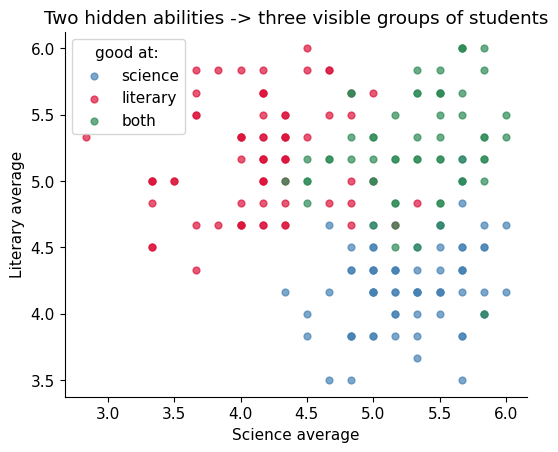

science students: high science / low literary;  literary: the opposite;  both: high on both.
PCA will recover these axes from the raw grades, without being told the types.


In [3]:
# --- The two summary scores, coloured by (hidden) student type (provided)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for t in TYPES:
    m = student_type == t
    ax.scatter(science[m], literary[m], color=TYPE_COLORS[t], alpha=0.7, s=24, label=t)
ax.set_xlabel('Science average'); ax.set_ylabel('Literary average')
ax.set_title('Two hidden abilities -> three visible groups of students')
ax.legend(title="good at: "); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print('science students: high science / low literary;  literary: the opposite;  both: high on both.')
print('PCA will recover these axes from the raw grades, without being told the types.')

> **▶ Task 2.1: Science vs literary, plot and correlate. _(Medium, easy with hints)_**
>
> The two averages tend to **trade off**: students strong in the sciences are often a bit weaker in the
> humanities. Let's see it.
> 1. Scatter each student's **science average** (x-axis) against their **literary average** (y-axis) (you can reuse the code from the cell above).
> 2. Compute their **correlation coefficient** and show it in the plot title (see hint if necessary).
> 3. Overlay the **best-fit straight line** so the trend is visible.

<details>
<summary>💡 Hint (click to show)</summary>

- `np.corrcoef(x, y)` returns a 2×2 matrix, the correlation you want is the off-diagonal entry `[0, 1]`.
- `np.polyfit(x, y, 1)` returns the line's `(slope, intercept)`.

</details>

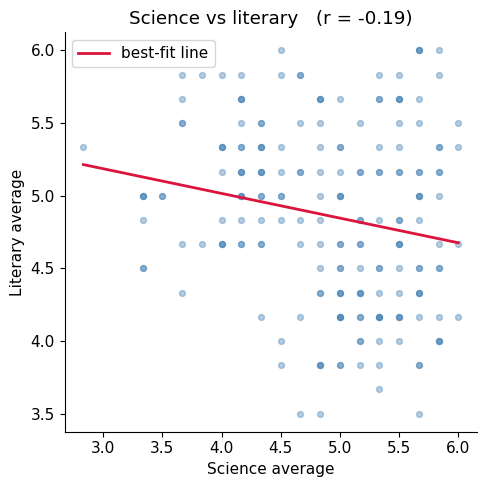

Correlation between the science and literary averages: r = -0.19  (negative = trade-off)


In [4]:
# TODO 2.1, scatter science vs literary average, correlate, and draw the best-fit line
r = np.corrcoef(science, literary)[0, 1]                     # TO BE REMOVED
slope, intercept = np.polyfit(science, literary, 1)          # TO BE REMOVED  best-fit line

fig, ax = plt.subplots(figsize=(5, 5))                       # TO BE REMOVED
ax.scatter(science, literary, alpha=0.4, s=18, color='steelblue')  # TO BE REMOVED
xs = np.array([science.min(), science.max()])               # TO BE REMOVED
ax.plot(xs, intercept + slope * xs, color='crimson', lw=2, label='best-fit line')  # TO BE REMOVED
ax.set_xlabel('Science average'); ax.set_ylabel('Literary average')  # TO BE REMOVED
ax.set_title(f'Science vs literary   (r = {r:.2f})'); ax.legend()    # TO BE REMOVED
plt.tight_layout(); plt.show()                              # TO BE REMOVED
print(f'Correlation between the science and literary averages: r = {r:.2f}  (negative = trade-off)')  # TO BE REMOVED

Task 2.2 stacks the two averages into a small data matrix and centres it:

- `SciLit`, the data matrix: one row per student, two columns `[science average, literary average]`.
- `Xc2`, the **centred** data: `SciLit` with each column's mean subtracted, so every column averages to 0
  (PCA always centres before measuring variance).
- `n`, the number of students (rows of `SciLit`).

The covariance is then built from `Xc2.T @ Xc2` divided by a normalising factor, and *which* factor is
exactly what the task below is about.

> **▶ Task 2.2: Fix the covariance bug. _(Easy)_**
>
> The cell computes the covariance of the **science** and **literary** averages by hand, but divides by
> the wrong factor. Uncomment the broken line, read the wrong numbers, then fix it.
>
<details>
<summary>💡 Hint (click to show)</summary>
The empirical covariance divides by $n-1$ (Bessel's correction), not $n^2$.
</details>

In [5]:
# TODO 2.2, fix the bug
SciLit = np.column_stack([science, literary])   # each student's (science avg, literary avg)
Xc2    = SciLit - SciLit.mean(axis=0)
n      = len(Xc2)

# BROKEN (uncomment and run, then fix):
# Sigma = (Xc2.T @ Xc2) / (n ** 2)

Sigma = (Xc2.T @ Xc2) / (n - 1)            # TO BE REMOVED
print('Covariance:\n', Sigma.round(3))
print('np.cov reference:\n', np.cov(SciLit.T).round(3))

Covariance:
 [[ 0.487 -0.083]
 [-0.083  0.374]]
np.cov reference:
 [[ 0.487 -0.083]
 [-0.083  0.374]]


### The covariance matrix and its eigenvectors

The **covariance matrix** $\Sigma$ says how the two averages co-vary. PCA finds its **eigenvectors**, the principal directions of variance:

$$\Sigma\,\mathbf v = \lambda\,\mathbf v$$

Because science and literary averages trade off, the first eigenvector points along the
*science-vs-literary* contrast; the second along the *good-at-both* (overall level) axis.

In the cell below, `Sigma` ($\Sigma$) is that 2×2 covariance matrix (here via `np.cov`), and `vals`,
`vecs` are its **eigenvalues** (the variance $\lambda$ along each principal direction) and
**eigenvectors** (the principal directions themselves).

Covariance matrix (science, literary):
 [[ 0.487 -0.083]
 [-0.083  0.374]]
  PC 1: lambda = 0.531  direction = [-0.884  0.468]
  PC 2: lambda = 0.330  direction = [-0.468 -0.884]


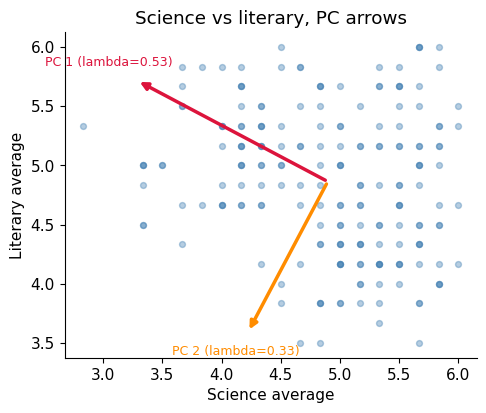

In [6]:
# --- Covariance and eigenvectors of the two averages (provided)
def plot_with_pcs(X, title='', xlabel='Feature A', ylabel='Feature B'):
    """Scatter X (n x 2) with arrows along its principal directions (provided helper)."""
    mu = X.mean(axis=0)
    S  = np.cov(X.T)
    vals, vecs = np.linalg.eigh(S)
    order = np.argsort(vals)[::-1]; vals, vecs = vals[order], vecs[:, order]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(X[:, 0], X[:, 1], alpha=0.4, s=18, color='steelblue')
    for i, col in enumerate(['crimson', 'darkorange']):
        arr = 2.5 * np.sqrt(vals[i]) * vecs[:, i]
        ax.annotate('', xy=mu + arr, xytext=mu,
                    arrowprops=dict(arrowstyle='-|>', color=col, lw=2.5))
        ax.text(*(mu + arr*1.15), f'PC {i+1} (lambda={vals[i]:.2f})',
                color=col, fontsize=9, ha='center')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title); ax.set_aspect('equal')
    plt.tight_layout(); plt.show()
    return vals
SciLit = np.column_stack([science, literary])
Sigma  = np.cov(SciLit.T)
print('Covariance matrix (science, literary):\n', Sigma.round(3))

vals, vecs = np.linalg.eigh(Sigma)
order = np.argsort(vals)[::-1]; vals, vecs = vals[order], vecs[:, order]
for k in range(2):
    print(f'  PC {k+1}: lambda = {vals[k]:.3f}  direction = {vecs[:, k].round(3)}')

_ = plot_with_pcs(SciLit, title='Science vs literary, PC arrows',
                  xlabel='Science average', ylabel='Literary average')

<a id="section-3"></a>
## 3. PCA with scikit-learn: the whole report card at once

Two classes were easy to draw. PCA earns its keep with **many** features, here all six
classes together. We **standardise** first (`StandardScaler`: subtract each class mean,
divide by its SD) so every class contributes on equal footing; §4 shows *why* this matters.

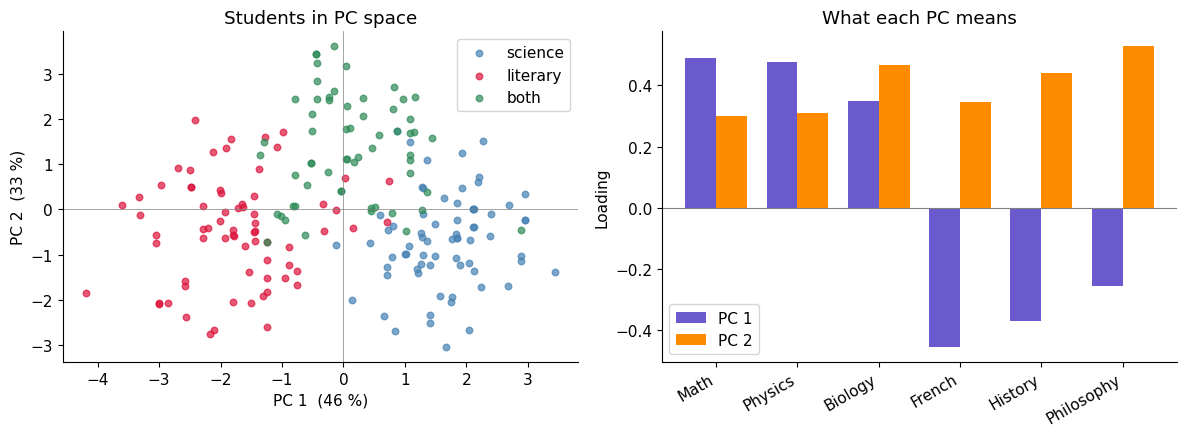

PC1 46%, PC2 33%  -> two hidden abilities, two dominant PCs.


In [7]:
# --- PCA on all six classes, coloured by (hidden) student type (provided)
G_z        = StandardScaler().fit_transform(G)
pca_grades = PCA().fit(G_z)
S_grades   = pca_grades.transform(G_z)
evr        = pca_grades.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for t in TYPES:
    m = student_type == t
    axes[0].scatter(S_grades[m, 0], S_grades[m, 1], color=TYPE_COLORS[t],
                    alpha=0.7, s=22, label=t)
axes[0].axhline(0, lw=.5, color='gray'); axes[0].axvline(0, lw=.5, color='gray')
axes[0].set_xlabel(f'PC 1  ({evr[0]*100:.0f} %)'); axes[0].set_ylabel(f'PC 2  ({evr[1]*100:.0f} %)')
axes[0].set_title('Students in PC space'); axes[0].legend()

x = np.arange(n_classes); w = 0.38
axes[1].bar(x - w/2, pca_grades.components_[0], w, label='PC 1', color='slateblue')
axes[1].bar(x + w/2, pca_grades.components_[1], w, label='PC 2', color='darkorange')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES, rotation=30, ha='right')
axes[1].set_ylabel('Loading'); axes[1].set_title('What each PC means'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'PC1 {evr[0]*100:.0f}%, PC2 {evr[1]*100:.0f}%  -> two hidden abilities, two dominant PCs.')

> **▶ Task 3.1: Read the loadings. _(Easy)_**
>
> Using `pca_grades.components_`:
> 1. Print the PC 1 loading for each class. Which classes have the same sign, which differ?
> 2. In one sentence each: what real-world axis does **PC 1** represent? And **PC 2**?
> 3. A student has a high **positive** PC 2 score but a PC 1 score near 0. What kind of
>    student are they, in plain words?

In [8]:
# TODO 3.1, your code here
for i in range(2):                                                                  # TO BE REMOVED
    print(f'PC{i+1} loadings:', {c: round(float(w), 2) for c, w in zip(CLASSES, pca_grades.components_[i])})  # TO BE REMOVED
print('\nPC 1 = science vs literary: the two groups get OPPOSITE-sign loadings')   # TO BE REMOVED
print('       (which group is + is arbitrary, see the interpretation-traps section).')  # TO BE REMOVED
print('PC 2 = overall level: every class loads with the SAME sign.')               # TO BE REMOVED
print('High PC2, PC1 ~ 0  -> strong in BOTH science and literary (an all-rounder).')  # TO BE REMOVED

PC1 loadings: {'Math': 0.49, 'Physics': 0.48, 'Biology': 0.35, 'French': -0.46, 'History': -0.37, 'Philosophy': -0.26}
PC2 loadings: {'Math': 0.3, 'Physics': 0.31, 'Biology': 0.47, 'French': 0.35, 'History': 0.44, 'Philosophy': 0.53}

PC 1 = science vs literary: the two groups get OPPOSITE-sign loadings
       (which group is + is arbitrary, see the interpretation-traps section).
PC 2 = overall level: every class loads with the SAME sign.
High PC2, PC1 ~ 0  -> strong in BOTH science and literary (an all-rounder).


### Scree plot and reconstruction

A **scree plot** shows the variance carried by each PC. Because the grades were built from
only **two** hidden abilities, two PCs should capture almost everything; the rest is noise.
Reconstructing from $k$ PCs and measuring the error makes that dimensionality visible.

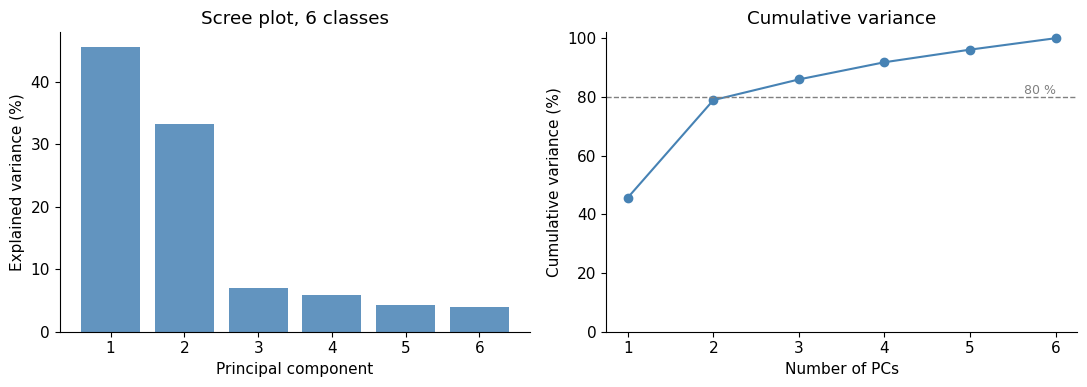

First two PCs explain 79% of all variance in the 6 grades.


In [9]:
# --- Scree + cumulative variance for the grades (provided)
cum = np.cumsum(evr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(1, n_classes+1), evr*100, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree plot, 6 classes')
axes[1].plot(np.arange(1, n_classes+1), cum*100, 'o-', color='steelblue')
axes[1].axhline(80, ls='--', color='gray', lw=1)
axes[1].text(n_classes, 81, '80 %', ha='right', color='gray', fontsize=9)
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative variance'); axes[1].set_ylim(0, 102)
plt.tight_layout(); plt.show()
print(f'First two PCs explain {cum[1]*100:.0f}% of all variance in the 6 grades.')

> **▶ Task 3.2: Fix the reconstruction bug. _(Easy)_**
>
> The cell calls `inverse_transform` before the PCA is fitted. Uncomment the broken block,
> read the error, then fix the order. Try `k = 1, 2, 3` and watch the error drop.

In [10]:
# TODO 3.2, fix the bug
k     = 2
pca_k = PCA(n_components=k)

# BROKEN order (uncomment, run, then fix):
# G_rec = pca_k.inverse_transform(pca_k.transform(G_z))
# pca_k.fit(G_z)

S_k   = pca_k.fit_transform(G_z)                 # TO BE REMOVED
G_rec = pca_k.inverse_transform(S_k)             # TO BE REMOVED
mse = np.mean((G_z - G_rec) ** 2)
print(f'k={k}  MSE={mse:.4f}  variance kept={pca_k.explained_variance_ratio_.sum()*100:.1f}%')

k=2  MSE=0.2109  variance kept=78.9%


> **▶ Task 3.3: Reconstruction-error curve. _(Medium)_**
>
> Fill in the loop to compute reconstruction MSE for `k = 1 … 6`. Plot MSE vs `k`. Where is
> the "elbow", and does it match the number of hidden abilities built into the data?

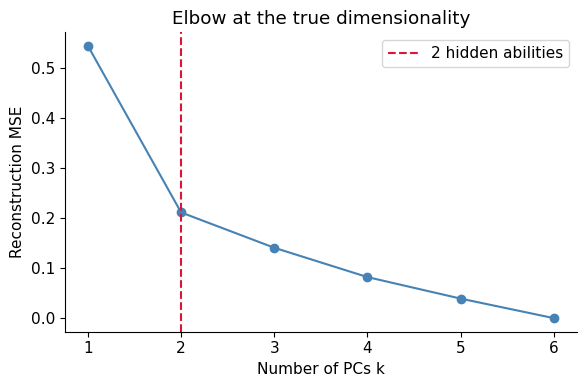

In [11]:
# TODO 3.3, fill in the loop
k_values, mse_values = np.arange(1, n_classes+1), []
for k in k_values:
    ...                                                         # TODO: reconstruct with k PCs, then mse_values.append(...)
    pca_k = PCA(n_components=k)                                  # TO BE REMOVED
    G_rec = pca_k.inverse_transform(pca_k.fit_transform(G_z))   # TO BE REMOVED
    mse_values.append(np.mean((G_z - G_rec) ** 2))              # TO BE REMOVED
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, mse_values, 'o-', color='steelblue')                  # TO BE REMOVED
ax.axvline(2, ls='--', color='crimson', lw=1.5, label='2 hidden abilities')  # TO BE REMOVED
ax.set_xlabel('Number of PCs k'); ax.set_ylabel('Reconstruction MSE')   # TO BE REMOVED
ax.set_title('Elbow at the true dimensionality'); ax.legend()           # TO BE REMOVED
plt.tight_layout(); plt.show()                                          # TO BE REMOVED

### Whitening: decorrelating and equalising the scores  *(optional, if you are lagging behind a bit feel free to jump to section 4)*

By default PCA only *rotates* the data onto the principal axes; the scores keep the
eigenvalue scaling (PC 1 has the largest spread). **Whitening** additionally divides each
score by $\sqrt{\lambda_i}$, giving the scores **identity covariance**, decorrelated and
unit-variance:

$$z_i \;\to\; z_i / \sqrt{\lambda_i}$$

Whitening helps methods that expect isotropic inputs (k-means, many classifiers, ICA). It
*hurts* when eigenvalue sizes are meaningful (a scree/elbow) or when small PCs are mostly
noise, whitening inflates that noise to the scale of the signal.

(Background: [whitening transformation](https://en.wikipedia.org/wiki/Whitening_transformation).)


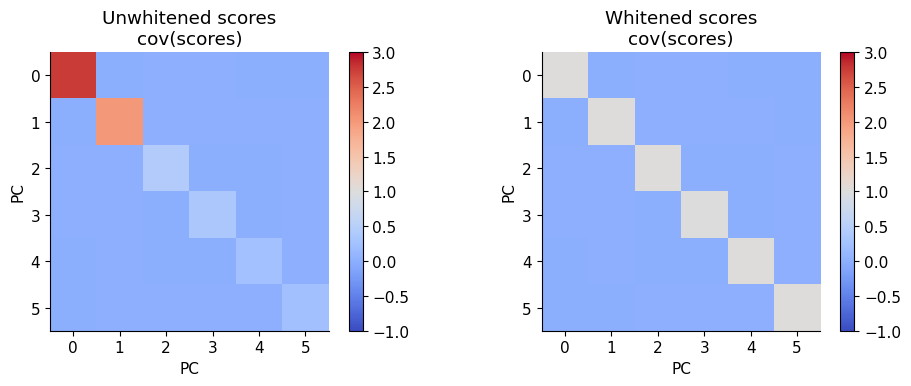

Unwhitened diag = eigenvalues (decreasing): [2.75 2.   0.43 0.35]
Whitened   diag ~ 1  (identity covariance) : [1. 1. 1. 1.]


In [12]:
# --- Whitening: effect on the score covariance (provided)
pca_nw = PCA(n_components=n_classes, whiten=False).fit(G_z)
pca_w  = PCA(n_components=n_classes, whiten=True ).fit(G_z)
Z_nw, Z_w = pca_nw.transform(G_z), pca_w.transform(G_z)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, Zc, title in [(axes[0], Z_nw, 'Unwhitened scores'),
                      (axes[1], Z_w,  'Whitened scores')]:
    im = ax.imshow(np.cov(Zc.T), cmap='coolwarm', vmin=-1, vmax=3)
    ax.set_title(f'{title}\ncov(scores)'); ax.set_xlabel('PC'); ax.set_ylabel('PC')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print('Unwhitened diag = eigenvalues (decreasing):', np.diag(np.cov(Z_nw.T))[:4].round(2))
print('Whitened   diag ~ 1  (identity covariance) :', np.diag(np.cov(Z_w.T))[:4].round(2))

> **▶ Task 3.4: When does whitening help? _(Easy, optional, at home)_**
>
> 1. Confirm the whitened scores have unit variance: print `Z_w.var(axis=0)` (first 4 PCs).
> 2. Print `pca_nw.explained_variance_`. The last PCs are tiny (noise). In one sentence,
>    why does whitening amplify them?
> 3. For a scree / "how many PCs" decision, should you whiten *before* or *after*? Why?

In [13]:
# TODO 3.4, your code here
print('Whitened score variances (PC1-4):', Z_w.var(axis=0)[:4].round(3))     # TO BE REMOVED
print('Eigenvalues:', pca_nw.explained_variance_.round(3))                   # TO BE REMOVED
print('\nWhitening divides each score by sqrt(eigenvalue), so tiny noise PCs get')  # TO BE REMOVED
print('blown up to unit variance, noise ends up as large as the signal.')          # TO BE REMOVED
print('Decide k on the UNWHITENED eigenvalues; whiten only afterwards if needed.')  # TO BE REMOVED

Whitened score variances (PC1-4): [0.995 0.995 0.995 0.995]
Eigenvalues: [2.755 2.004 0.425 0.353 0.259 0.235]

Whitening divides each score by sqrt(eigenvalue), so tiny noise PCs get
blown up to unit variance, noise ends up as large as the signal.
Decide k on the UNWHITENED eigenvalues; whiten only afterwards if needed.


<a id="section-4"></a>
## 4. Under the hood (SVD) and why preprocessing matters

In Section 2 we found the principal directions by taking the **eigenvectors of the covariance matrix**.
That works, but building $X^\top X$ squares the numbers and can quietly lose precision. In practice PCA,
`sklearn.PCA` included, is computed straight from the data with the **Singular Value Decomposition (SVD)**,
which gives the *same* directions and eigenvalues more stably. This section opens the box: we run the SVD
by hand, check it against `sklearn`, and then use it to see exactly how **centering** and **scaling**
change the answer. Get those two steps wrong and PCA will confidently hand you the wrong axes.


### PCA via SVD

Take the data matrix $X$ ($n$ students $\times$ $p$ classes), with each **column centred to mean 0**. It
always factorises as

$$X = U\,S\,V^\top .$$

Read it one factor at a time:

- $V$ is $p \times p$: **each column is a principal direction** (a loading, a unit vector in feature
  space). These are *exactly* the covariance eigenvectors from Section 2, obtained without ever forming a
  covariance matrix.
- $S$ is diagonal, holding the **singular values** $s_1 \ge s_2 \ge \dots \ge 0$, which rank the
  directions by how much the data spreads along each. The variance along direction $i$ (its eigenvalue) is
  $\lambda_i = s_i^{2} / (n-1)$.
- $U$ is $n \times p$: the same points in rotated, unit-scaled coordinates. Scaling those columns back up
  by the singular values gives the **scores**, each student's position on the PCs: $\;X V = U S$.

So the whole recipe is: **centre $X$, take its SVD, read the loadings off $V$, the scores off $US$
(equivalently $XV$), and convert singular values to explained variance with $s_i^{2}/(n-1)$.** The cell
below does precisely this and confirms it reproduces the numbers `sklearn` returns.


In [14]:
# --- Manual SVD-based PCA on the grades, verify it matches sklearn (provided) ---
# Step 1: centre every feature (column) to mean 0. PCA describes variation AROUND the mean, so this is
#         not optional (the centering demo just below shows what goes wrong if you skip it). G_z is
#         already z-scored (mean 0), so this line is a harmless safety net that keeps the recipe complete.
Xc = G_z - G_z.mean(axis=0)

# Step 2: factorise the centred data,  Xc = U @ diag(s) @ Vt.
#         full_matrices=False gives the compact ("economy") SVD: U is (n, p), s is (p,), Vt is (p, p).
#         The ROWS of Vt (= columns of V) are the principal directions / loadings, ordered by s.
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

# Step 3: turn each singular value into the variance its PC explains:  lambda_i = s_i^2 / (n - 1).
eig_svd = s**2 / (len(Xc) - 1)

# Step 4: the by-hand eigenvalues should match sklearn's explained_variance_ to the last digit.
print('Manual SVD eigenvalues    :', eig_svd[:4].round(3))
print('sklearn explained_variance:', PCA().fit(G_z).explained_variance_[:4].round(3))
print('Variance explained (%)    :', (eig_svd / eig_svd.sum() * 100).round(1))


Manual SVD eigenvalues    : [2.755 2.004 0.425 0.353]
sklearn explained_variance: [2.755 2.004 0.425 0.353]
Variance explained (%)    : [45.7 33.2  7.   5.9  4.3  3.9]


> **▶ Task 4.1: Implement `pca_svd(X, k)`. _(Medium)_**
>
> Complete the function (you can copy/paste from the cell above): centre `X`, run SVD, return scores (n×k), components (k×p), and
> explained-variance ratio (k,). Verify it matches sklearn on the grades.

In [15]:
# TODO 4.1, complete pca_svd
def pca_svd(X, k):
    """PCA via SVD. Returns (scores, components, var_ratio)."""
    n        = X.shape[0]
    Xc       = X - X.mean(axis=0)                       # TO BE REMOVED
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)   # TO BE REMOVED
    eigs     = s**2 / (n - 1)                            # TO BE REMOVED
    vr       = eigs / eigs.sum()                         # TO BE REMOVED
    return Xc @ Vt[:k].T, Vt[:k], vr[:k]               # TO BE REMOVED

sc_m, co_m, vr_m = pca_svd(G_z, k=3)
ref = PCA(n_components=3).fit(G_z)
print('Var ratio, manual:', vr_m.round(4))
print('Var ratio, sklearn:', ref.explained_variance_ratio_.round(4))
print('Match:', np.allclose(vr_m, ref.explained_variance_ratio_, atol=1e-5))

Var ratio, manual: [0.4568 0.3323 0.0705]
Var ratio, sklearn: [0.4568 0.3323 0.0705]
Match: True


### Centering: or PC 1 just finds the average student

PCA explains variance **around the mean**, so you must subtract the mean first. Forget,
and PC 1 points at the *mean grade vector* instead of the structure. It gets worse with a
**lenient teacher**: a class with a high average grade dominates the uncentred PCA, as if
that class mattered most, purely because its numbers are large.

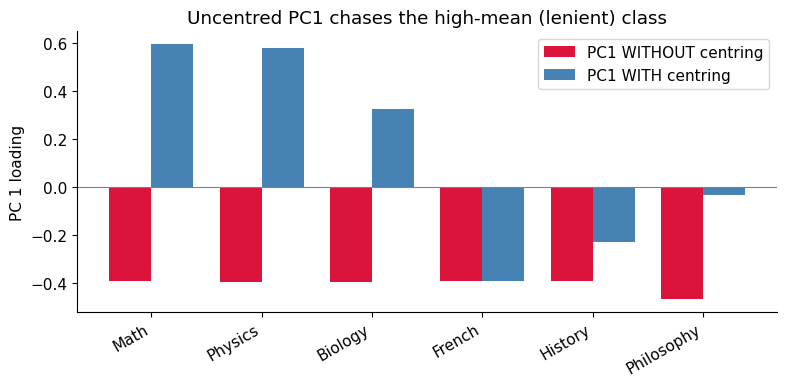

Class means: {'Math': 4.87, 'Physics': 4.91, 'Biology': 4.92, 'French': 4.85, 'History': 4.85, 'Philosophy': 5.82}
Uncentred PC1 ~ the mean-grade direction (all the same sign, largest on Philosophy);
centred PC1 recovers the science-vs-literary contrast.


In [16]:
# --- A lenient Philosophy teacher (+1.3 to everyone) breaks UNcentred PCA (provided)
G_lenient = G.copy()
_phil = CLASSES.index('Philosophy')
G_lenient[:, _phil] = np.clip(G_lenient[:, _phil] + 1.3, 1, 6)

def pca_no_centre(X, k=2):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)   # NB: no centring
    return Vt[:k]

v_nc = pca_no_centre(G_lenient)
v_c  = PCA(n_components=2).fit(G_lenient).components_   # sklearn centres for you

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(n_classes); w = 0.38
ax.bar(x - w/2, v_nc[0], w, label='PC1 WITHOUT centring', color='crimson')
ax.bar(x + w/2, v_c[0],  w, label='PC1 WITH centring',    color='steelblue')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('PC 1 loading'); ax.set_title('Uncentred PC1 chases the high-mean (lenient) class')
ax.legend(); plt.tight_layout(); plt.show()
print('Class means:', {c: round(float(v), 2) for c, v in zip(CLASSES, G_lenient.mean(0))})
print('Uncentred PC1 ~ the mean-grade direction (all the same sign, largest on Philosophy);')
print('centred PC1 recovers the science-vs-literary contrast.')

> **▶ Task 4.2: Why does forgetting to centre corrupt PCA? _(Medium)_**
>
> 1. Compute the variance explained by PC 1 **with** vs **without** centring.
> 2. In 2–3 sentences: why does the uncentred PC 1 line up with the mean grade vector, and
>    why does a lenient teacher (high class mean) make it worse?

In [17]:
# TODO 4.2, your code here
U, s, Vt = np.linalg.svd(G_lenient, full_matrices=False)            # TO BE REMOVED
vr_nc = s**2 / (len(G_lenient) - 1); vr_nc = vr_nc / vr_nc.sum()    # TO BE REMOVED
vr_c  = PCA().fit(G_lenient).explained_variance_ratio_             # TO BE REMOVED
print(f'PC1 variance WITHOUT centring: {vr_nc[0]*100:.1f}%')       # TO BE REMOVED
print(f'PC1 variance WITH centring   : {vr_c[0]*100:.1f}%')       # TO BE REMOVED
print('\nWithout centring, every grade is ~5 (far from 0), so the biggest "direction"')   # TO BE REMOVED
print('is just the common offset, the mean vector. The lenient class has the largest')    # TO BE REMOVED
print('values, so it dominates that offset and soaks up PC1.')                             # TO BE REMOVED

PC1 variance WITHOUT centring: 98.6%
PC1 variance WITH centring   : 55.4%

Without centring, every grade is ~5 (far from 0), so the biggest "direction"
is just the common offset, the mean vector. The lenient class has the largest
values, so it dominates that offset and soaks up PC1.


### Scaling: when classes use different grading systems

Centring is not enough if features live on **different scales**. Suppose an exchange
student's **French** grade comes back on the French **/20** system while everything else is
Swiss **/6**. The /20 column now has ~3× the spread, so it dominates the variance and PCA
points almost entirely at it, even though nothing about the students changed.
**Standardising** (z-scoring) each class first puts them back on equal footing.

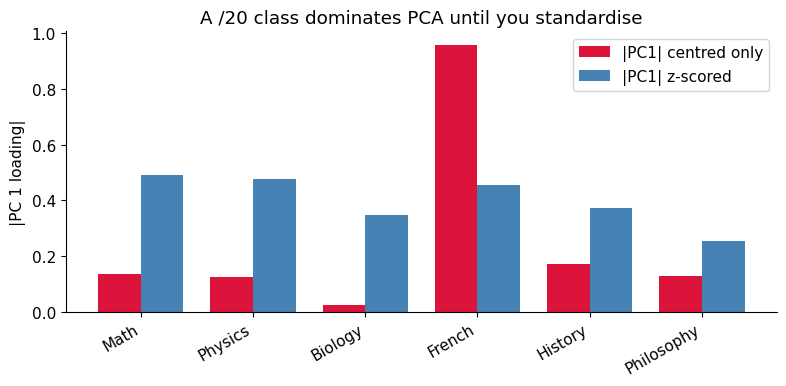

Class SDs: {'Math': 0.86, 'Physics': 0.85, 'Biology': 0.63, 'French': 2.7, 'History': 0.68, 'Philosophy': 0.62}
Centred-only PC1 loads almost entirely on French (biggest SD); z-scoring fixes it.


In [18]:
# --- French regraded on /20 hijacks PCA unless we standardise (provided)
G_mixed = G.copy()
G_mixed[:, CLASSES.index('French')] *= 20 / 6     # French now on a /20 scale

pc_unscaled = PCA(n_components=2).fit(G_mixed - G_mixed.mean(0))              # centred only
pc_scaled   = PCA(n_components=2).fit(StandardScaler().fit_transform(G_mixed))  # z-scored

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(n_classes); w = 0.38
ax.bar(x - w/2, np.abs(pc_unscaled.components_[0]), w, label='|PC1| centred only', color='crimson')
ax.bar(x + w/2, np.abs(pc_scaled.components_[0]),   w, label='|PC1| z-scored',     color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('|PC 1 loading|'); ax.set_title('A /20 class dominates PCA until you standardise')
ax.legend(); plt.tight_layout(); plt.show()
print('Class SDs:', {c: round(float(v), 2) for c, v in zip(CLASSES, G_mixed.std(0))})
print('Centred-only PC1 loads almost entirely on French (biggest SD); z-scoring fixes it.')

> **▶ Task 4.3: Centre vs standardise. _(Medium)_**
>
> 1. Print each class's standard deviation in `G_mixed`. Which is largest?
> 2. Print the PC 1 loadings centred-only vs z-scored. How much does the French loading
>    shrink after standardising?
> 3. **Question:** give one situation where you would *not* want to standardise before PCA.

In [19]:
# TODO 4.3, your code here
print('SDs:', {c: round(float(v), 2) for c, v in zip(CLASSES, G_mixed.std(0))})                            # TO BE REMOVED
print('PC1 centred-only:', {c: round(float(v), 2) for c, v in zip(CLASSES, pc_unscaled.components_[0])})   # TO BE REMOVED
print('PC1 z-scored    :', {c: round(float(v), 2) for c, v in zip(CLASSES, pc_scaled.components_[0])})     # TO BE REMOVED
print('\nFrench loading shrinks from ~1.0 to ~0.5 after standardising.')             # TO BE REMOVED
print('Do NOT standardise when features share units and their relative scale is')      # TO BE REMOVED
print('meaningful (e.g. all grades already on /6, or PSD bins in the same units).')    # TO BE REMOVED

SDs: {'Math': 0.86, 'Physics': 0.85, 'Biology': 0.63, 'French': 2.7, 'History': 0.68, 'Philosophy': 0.62}
PC1 centred-only: {'Math': -0.14, 'Physics': -0.13, 'Biology': -0.03, 'French': 0.96, 'History': 0.17, 'Philosophy': 0.13}
PC1 z-scored    : {'Math': 0.49, 'Physics': 0.48, 'Biology': 0.35, 'French': -0.46, 'History': -0.37, 'Philosophy': -0.26}

French loading shrinks from ~1.0 to ~0.5 after standardising.
Do NOT standardise when features share units and their relative scale is
meaningful (e.g. all grades already on /6, or PSD bins in the same units).


<a id="section-5"></a>
## 5. The Alpha Waves dataset

Time for real brains. The **EEG Alpha Waves** dataset (Cattan, Rodrigues & Congedo, GIPSA-lab; Zenodo
`10.5281/zenodo.2348892`) records **16-channel** scalp EEG (10-20 system, 512 Hz) while each subject
alternates two resting states, five blocks of ten seconds each:

- **eyes closed**, the occipital **alpha rhythm** (8–12 Hz) surges over posterior electrodes;
- **eyes open**, alpha is suppressed and the spectrum is flatter.

This is a clean **two-class** problem with a strong, spatially specific signature, an honest test of what
PCA does (and does not) surface on real multi-subject data.

The recordings ship **with the repository** as `data/alphawaves.npz`, **repackaged** from the original
Zenodo `.mat` files into raw 10-s blocks (see `data/eeg_datadictionary.md` for the layout), so nothing
needs downloading. The next cell epochs them on the fly: downsample to 128 Hz and cut each block into 2-s
epochs. (To rebuild the raw file from the original Zenodo `.mat` files, see `data_prep/build_alpha_dataset.py`.)

In [20]:
# --- Load the committed Alpha Waves recordings and cut them into epochs (provided) ---
# The repo ships the raw eyes-open/closed blocks in data/alphawaves.npz (10-s blocks at 256 Hz), so no
# download is needed. We epoch them here: detrend each block, downsample to 128 Hz, drop 1 s at each edge
# (onset settling + filter transients), then split into 2-s epochs.
from scipy.signal import decimate, detrend

_raw       = np.load(RAW_PATH, allow_pickle=True)
raw_blocks = _raw['X'].astype(np.float64)                  # (n_blocks, 16, 2560) at 256 Hz
ch_names   = [c[0].upper() + c[1:].lower() for c in _raw['ch_names']]   # 'FP1' -> 'Fp1', 'OZ' -> 'Oz', etc.
sfreq      = TARGET_SFREQ                                   # 128 Hz after downsampling
_decim     = int(round(float(_raw['sfreq']) / sfreq))      # 256 -> 128 Hz  (factor 2)
_crop_n, _epoch_n = int(CROP_S * sfreq), int(EPOCH_S * sfreq)

X_list, cond, subject = [], [], []
for _bi, _block in enumerate(raw_blocks):                  # one 10-s block per row
    b = detrend(_block.T, axis=0, type='linear')           # remove per-block drift BEFORE decimating
    b = decimate(b, _decim, axis=0, ftype='fir', zero_phase=True)      # downsample 256 -> 128 Hz
    b = b[_crop_n:len(b) - _crop_n]                         # drop 1 s at each edge
    for k in range(len(b) // _epoch_n):                    # split into 2-s epochs
        seg = detrend(b[k*_epoch_n:(k+1)*_epoch_n], axis=0, type='constant')   # remove residual DC
        X_list.append(seg.T.astype(np.float32))
        cond.append(1 if _raw['condition'][_bi] == 'eyes_closed' else 0)       # 1 = closed, 0 = open
        subject.append(int(str(_raw['subject'][_bi]).split('_')[1]))          # 'subject_03' -> 3
X_raw = np.stack(X_list)
cond = np.array(cond, dtype=int); subject = np.array(subject)
n_epochs, n_ch, n_samples_epoch = X_raw.shape

print(f'{n_epochs} epochs × {n_ch} channels × {n_samples_epoch} samples  @ {sfreq:.0f} Hz')
print(f'  eyes closed: {int((cond==1).sum())}   eyes open: {int((cond==0).sum())}   '
      f'subjects: {len(np.unique(subject))}')
print(f'  channels: {ch_names}')


800 epochs × 16 channels × 256 samples  @ 128 Hz
  eyes closed: 400   eyes open: 400   subjects: 20
  channels: ['Fp1', 'Fp2', 'Fc5', 'Fc6', 'Fz', 'T7', 'Cz', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']


In [21]:
# --- Turn each epoch into a spectral feature vector: one FFT per channel (provided) ---
# Goal: turn each (16-channel x 256-sample) epoch into ONE long feature vector, so PCA can treat each
# epoch as a single point. We take the power spectrum of every channel and stack them side by side,
# which gives n_ch * n_freq features per epoch.
print(f'Computing {FEATURE_MODE} FFT power features for {n_epochs} epochs ...', end=' ', flush=True)

_freqs   = np.fft.rfftfreq(n_samples_epoch, 1 / sfreq)   # the frequencies an FFT of this length returns
_f_mask  = (_freqs >= FREQ_LO) & (_freqs < FREQ_HI)      # keep only the 1-40 Hz band
freq_axis = _freqs[_f_mask]                              # frequencies we keep (the feature "x-axis")
n_freq   = int(_f_mask.sum())                            # number of frequency bins per channel

X_psd = np.zeros((n_epochs, n_ch * n_freq), dtype=np.float32)   # rows = epochs, cols = (channel, frequency)
for ei, epoch in enumerate(X_raw):                       # one row per epoch
    row = []
    for ch in range(n_ch):                               # one spectrum per channel
        psd = np.abs(np.fft.rfft(epoch[ch]))**2          # power spectrum = |FFT|^2 (energy at each frequency)
        p = psd[_f_mask]                                 # restrict to 1-40 Hz
        if FEATURE_MODE == 'relative':
            p = p / (p.sum() + 1e-20)                    # normalise to spectral SHAPE (removes overall amplitude)
            feat = 10.0 * np.log10(p + 1e-12)            # convert to decibels (tames the huge dynamic range)
        else:
            feat = np.log1p(p)                           # absolute log-power instead
        row.append(feat)
    X_psd[ei] = np.concatenate(row)                      # glue the 16 per-channel spectra into one long vector
print('done')

n_features = X_psd.shape[1]
print(f'Feature matrix X_psd: {X_psd.shape}  ({n_ch} channels × {n_freq} freq bins, '
      f'{FREQ_LO}–{FREQ_HI} Hz, {freq_axis[1]-freq_axis[0]:.2f} Hz/bin)')


Computing relative FFT power features for 800 epochs ... done
Feature matrix X_psd: (800, 1248)  (16 channels × 78 freq bins, 1.0–40.0 Hz, 0.50 Hz/bin)


> **▶ Task 5.1: Inspect the dataset. _(Very Easy)_**
>
> 1. What fraction of the epochs are eyes-closed vs eyes-open? Print both as percentages.
> 2. How many epochs did each subject contribute? (`np.unique(subject, return_counts=True)`.)
> 3. What is the shape of `X_psd`, and what does one **row** represent? One **column**?

In [22]:
# TODO 5.1, your code here
for c in (1, 0):                                                        # TO BE REMOVED
    print(f'  {COND_NAMES[c]:12s}: {(cond==c).mean()*100:5.1f} %')      # TO BE REMOVED
_subj, _n = np.unique(subject, return_counts=True)                      # TO BE REMOVED
print('epochs per subject:', dict(zip(_subj.tolist(), _n.tolist())))   # TO BE REMOVED
print(f'X_psd shape: {X_psd.shape}')                                    # TO BE REMOVED
print('Each row = one 2-s epoch; each column = the spectral feature at one (channel, frequency) pair.')  # TO BE REMOVED

  eyes closed :  50.0 %
  eyes open   :  50.0 %
epochs per subject: {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40, 6: 40, 8: 40, 9: 40, 10: 40, 11: 40, 12: 40, 13: 40, 14: 40, 15: 40, 16: 40, 17: 40, 18: 40, 19: 40, 20: 40}
X_psd shape: (800, 1248)
Each row = one 2-s epoch; each column = the spectral feature at one (channel, frequency) pair.


<a id="section-6"></a>
## 6. From raw EEG to a spectral feature matrix

Before running PCA, look at what the two conditions actually look like on a posterior channel. Eyes-closed
epochs should show a clear bump around 10 Hz; eyes-open epochs should not.

> **New here: the power spectrum.** A recording wiggles in *time*; its **power spectrum** re-describes the
> very same signal as *how much energy sits at each frequency*, a slow rhythm shows up at low Hz, a fast one
> at high Hz. Below we compute it with one `np.fft.rfft` per epoch and use the power at each frequency as a
> feature. Just take it as given for now: we cover the Fourier transform and spectral analysis properly in
> the coming weeks.


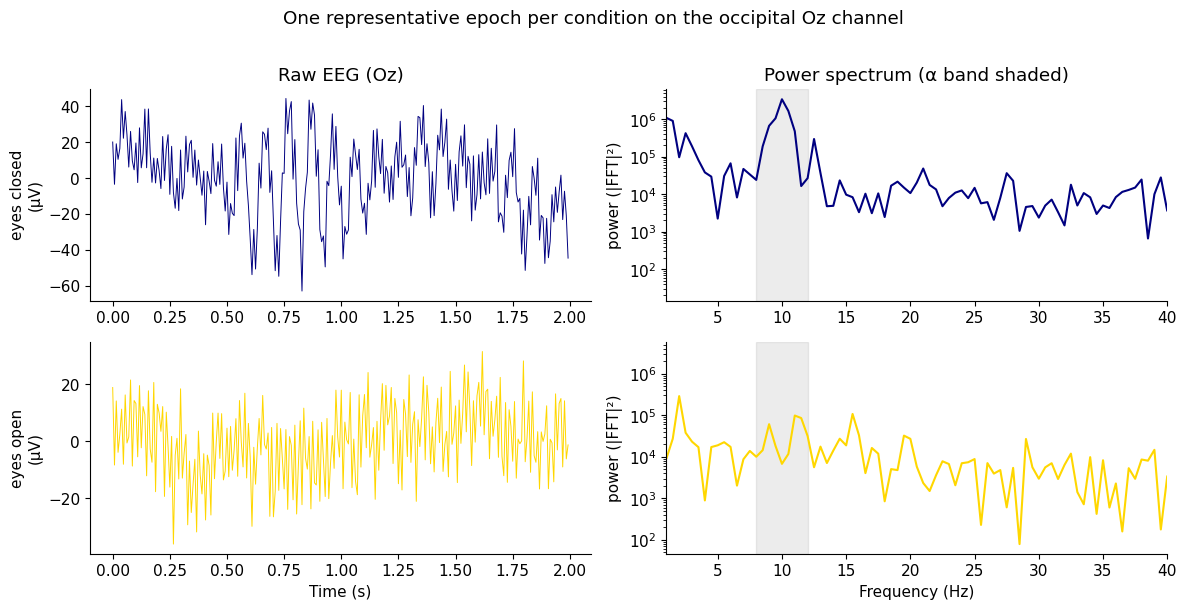

Eyes closed shows a clear peak in the 8–12 Hz alpha band on Oz; eyes open does not.


In [42]:
# --- One example epoch per condition on Oz, with its power spectrum (provided) ---
_oz = ch_names.index('Oz') if 'Oz' in ch_names else n_ch - 1
t_axis = np.arange(n_samples_epoch) / sfreq
freqs_full = np.fft.rfftfreq(n_samples_epoch, 1 / sfreq)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row, c in enumerate((1, 0)):                       # 1 = closed, 0 = open
    idx = np.where(cond == c)[0][0]
    ep  = X_raw[idx, _oz]
    axes[row, 0].plot(t_axis, ep, lw=0.7, color=COND_COLORS[c])
    axes[row, 0].set_ylabel(f'{COND_NAMES[c]}\n(µV)')
    if row == 1: axes[row, 0].set_xlabel('Time (s)')
    axes[row, 0].set_title('Raw EEG (Oz)' if row == 0 else '')
    psd = np.abs(np.fft.rfft(ep))**2
    axes[row, 1].semilogy(freqs_full[1:], psd[1:], color=COND_COLORS[c], lw=1.5)  # drop the 0 Hz (DC) bin
    axes[row, 1].axvspan(ALPHA_LO, ALPHA_HI, color='gray', alpha=0.15)
    axes[row, 1].set_xlim(1, 40); axes[row, 1].set_ylabel('power (|FFT|²)')
    if row == 1: axes[row, 1].set_xlabel('Frequency (Hz)')
    axes[row, 1].set_title('Power spectrum (α band shaded)' if row == 0 else '')
plt.suptitle('One representative epoch per condition on the occipital Oz channel', y=1.01)
plt.tight_layout(); plt.show()
print('Eyes closed shows a clear peak in the 8–12 Hz alpha band on Oz; eyes open does not.')

> **▶ Task 6.1: Mean spectrum per condition on Oz. _(Very Easy)_**
>
> For the **Oz** channel, average the per-bin spectral feature (`X_psd`) across all eyes-closed epochs and
> across all eyes-open epochs, and plot the two mean spectra on the same axes. Shade the alpha band.
>
> Hint: the Oz features are columns `_oz * n_freq : (_oz + 1) * n_freq` of `X_psd`; `freq_axis` gives the
> frequencies.

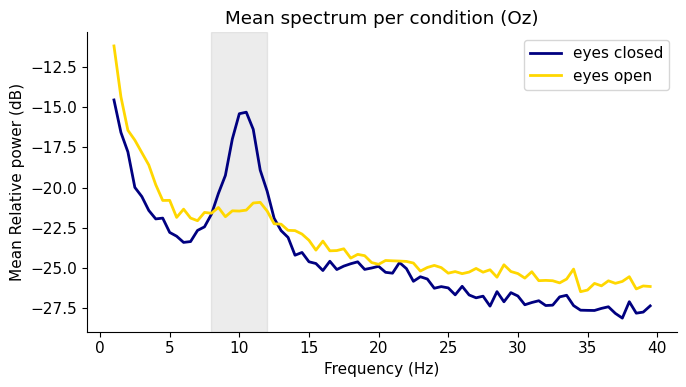

The eyes-closed mean spectrum sits above eyes-open across the alpha band on Oz.


In [24]:
# TODO 6.1, mean spectrum per condition on Oz
oz_cols = slice(_oz * n_freq, (_oz + 1) * n_freq)                          # TO BE REMOVED
fig, ax = plt.subplots(figsize=(7, 4))                                     # TO BE REMOVED
for c in (1, 0):                                                          # TO BE REMOVED
    ax.plot(freq_axis, X_psd[cond == c, oz_cols].mean(0),                 # TO BE REMOVED
            color=COND_COLORS[c], lw=2, label=COND_NAMES[c])              # TO BE REMOVED
ax.axvspan(ALPHA_LO, ALPHA_HI, color='gray', alpha=0.15)                  # TO BE REMOVED
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel(f'Mean {FEATURE_LABEL}')   # TO BE REMOVED
ax.set_title('Mean spectrum per condition (Oz)'); ax.legend()             # TO BE REMOVED
plt.tight_layout(); plt.show()                                            # TO BE REMOVED
print('The eyes-closed mean spectrum sits above eyes-open across the alpha band on Oz.')  # TO BE REMOVED

<a id="section-7"></a>
## 7. PCA on the spectral feature matrix

We now apply PCA to `X_psd` (n_epochs × n_features). Each epoch is one point in a high-dimensional space;
PCA finds the axes of maximal variance.

**Why z-score first?** The channels and frequency bands span very different scales. Z-scoring each feature
(mean 0, std 1 across epochs) prevents any single channel/frequency from dominating PC 1 by sheer magnitude.

PCA is **unsupervised**: it maximises variance, which need not be your effect. With 19 subjects pooled,
the biggest source of variance is *between subjects*, not eyes-open vs eyes-closed, so do not assume PC 1
is the condition. In Section 8 we *measure* which PC actually tracks it.

> **Note:** `scaler`, `X_z`, `pca_alpha`, `Z` and `ev` are fitted here and reused in the Part II sections that follow.

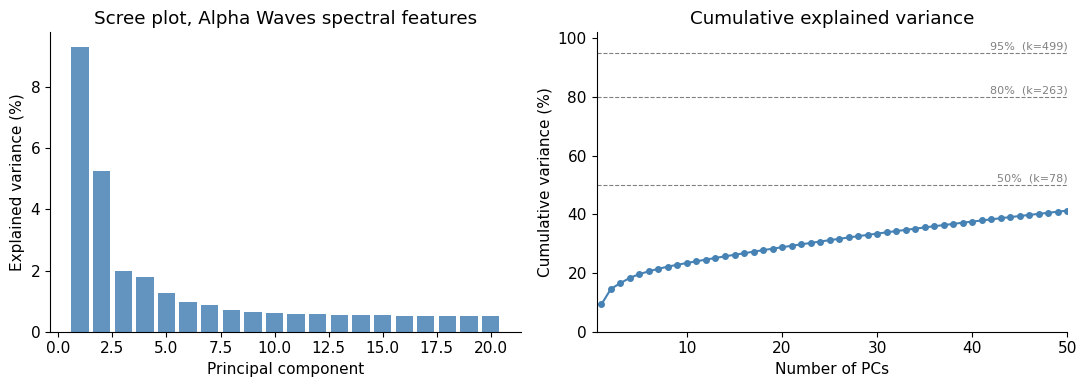

PC1 explains 9.3% of the variance; PC1+PC2 explain 14.6%.


In [25]:
# --- Z-score + fit PCA on the full feature matrix (provided) ---
# Z-score each feature (column) to mean 0 / std 1 first, so that no single channel-frequency dominates
# PC 1 just because its raw numbers happen to be larger. Then fit PCA on the standardised matrix.
scaler    = StandardScaler()
X_z       = scaler.fit_transform(X_psd)          # standardised features (n_epochs, n_features)
pca_alpha = PCA().fit(X_z)                        # fit all principal components
Z         = pca_alpha.transform(X_z)             # PC scores = each epoch's coordinates on the PCs (reused in Part II)
ev        = pca_alpha.explained_variance_ratio_  # fraction of total variance captured by each PC
cum_var   = np.cumsum(ev)                         # running total, for the cumulative plot

# Left panel: scree plot (variance per PC). Right panel: cumulative variance, marking how many PCs (k)
# are needed to reach 50 / 80 / 95 % of the total.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(1, 21), ev[:20]*100, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree plot, Alpha Waves spectral features')
axes[1].plot(np.arange(1, len(cum_var)+1), cum_var*100, 'o-', color='steelblue', markersize=4)
for thr in [50, 80, 95]:
    k = int(np.searchsorted(cum_var, thr/100)) + 1        # first k whose cumulative variance >= threshold
    axes[1].axhline(thr, ls='--', color='gray', lw=0.8)
    axes[1].text(min(n_features, 50), thr+0.5, f'{thr}%  (k={k})', va='bottom', ha='right', color='gray', fontsize=8)
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance'); axes[1].set_xlim(0.5, min(n_features, 50)); axes[1].set_ylim(0, 102)
plt.tight_layout(); plt.show()
print(f'PC1 explains {ev[0]*100:.1f}% of the variance; PC1+PC2 explain {cum_var[1]*100:.1f}%.')


> **Why is the scree so flat?** It takes ~80 PCs to reach 50% variance, a world away from the 2-PC grades
> toy. The cause is the feature itself: each column is a **single-epoch raw periodogram** value (one plain
> `|FFT|^2` from a 2-s epoch, no Welch or multitaper averaging). A raw periodogram is a very noisy spectral
> estimator, roughly 100% error at every frequency bin and near-independent across bins, so on top of the
> real structure every feature carries a large, near-independent noise term, and independent noise spreads
> variance across many PCs. Damp that per-epoch noise and the scree sharpens immediately: smoothing each
> spectrum over ~2 Hz drops 50% variance from ~80 PCs to ~7; averaging epochs within subject/condition, or
> collapsing to a few band-powers, to ~3. Add real between-subject heterogeneity (19 subjects, each with
> its own peak-alpha frequency and 1/f slope) and the fact that the eyes-open/closed effect is only a small
> slice of the total variance, and a flat scree is exactly what to expect. Real single-epoch EEG spectra
> are simply not low-rank, unlike the toy grades.


> **▶ Task 7.1: Which channel and frequency drive PC 1? _(Medium)_**
>
> The PC 1 loadings live in `pca_alpha.components_[0]`, one weight per `(channel, frequency)` feature.
> 1. Reshape them to `(n_ch, n_freq)` and find the `(channel, frequency)` with the **largest-magnitude**
>    loading. Which channel? Which frequency?
> 2. Does it land in the **alpha band** over a **posterior** channel, as the spectra suggested? (Do not be
>    surprised if it does not: PC 1 is the biggest-variance axis, not necessarily the effect of interest.)
>
> Hint: `np.abs(load2d).argmax()` + `np.unravel_index(...)`; `ch_names` and `freq_axis` give the labels.

In [26]:
# TODO 7.1, your code here
load2d = pca_alpha.components_[0].reshape(n_ch, n_freq)                 # TO BE REMOVED
ci, fi = np.unravel_index(np.abs(load2d).argmax(), load2d.shape)        # TO BE REMOVED
print(f'Largest |PC1 loading| at channel {ch_names[ci]}, {freq_axis[fi]:.1f} Hz '   # TO BE REMOVED
      f'(loading {load2d[ci, fi]:+.3f})')                              # TO BE REMOVED
print('PC1 largest loading is at a high frequency, NOT the alpha band, and it does not obviously')  # TO BE REMOVED
print('match the eyes-closed signature. PC1 is the top-variance axis, not necessarily the effect,')  # TO BE REMOVED
print('we test which PC actually separates the conditions in Section 8.')  # TO BE REMOVED

Largest |PC1 loading| at channel Oz, 34.0 Hz (loading +0.056)
PC1 largest loading is at a high frequency, NOT the alpha band, and it does not obviously
match the eyes-closed signature. PC1 is the top-variance axis, not necessarily the effect,
we test which PC actually separates the conditions in Section 8.


<a id="section-8"></a>
## 8. Eyes-open vs eyes-closed in PC space

Each epoch is now a single point in PC space. Rather than *assume* the effect is on PC 1, we score **every**
PC for how well it separates eyes-open from eyes-closed (a **Fisher ratio**) and let the data tell us where
the condition lives.

> **New here: the Fisher ratio.** It is the same *between-group vs within-group* variance idea as the
> **ANOVA F-statistic** you met earlier in the course: how far apart the two condition means are, divided by
> the scatter *within* each condition. Large means the conditions separate cleanly along that PC; near 0
> means they overlap. (Background: [Fisher's linear discriminant](https://en.wikipedia.org/wiki/Linear_discriminant_analysis#Fisher's_linear_discriminant).)


Fisher ratio (eyes-open vs closed) per PC:
  PC1: 0.006
  PC2: 0.158   <- condition axis
  PC3: 0.008
  PC4: 0.078
  PC5: 0.000
  PC6: 0.000
PC 1 barely separates the conditions; the effect lives on PC2. PC 1 is dominated by between-subject variance instead.


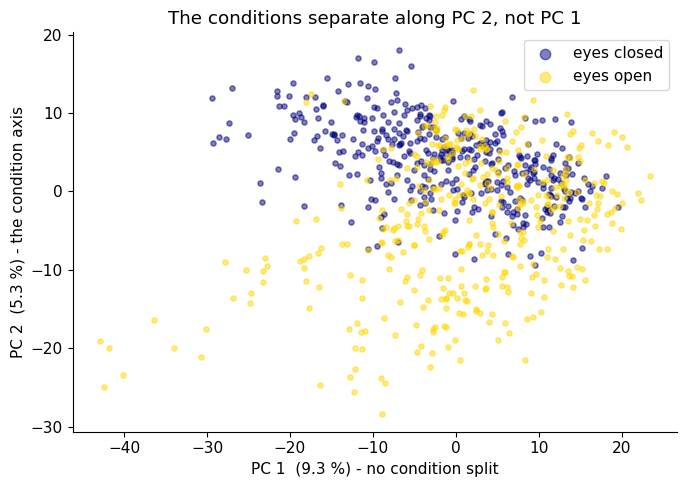

In [27]:
# --- Which PC actually tracks the condition? Score every PC, then look (provided) ---
def fisher_ratio(scores, labels):
    """Fisher ratio of a 1-D score: between-group variance of the class means
    divided by the mean within-group variance. Higher = better separated."""
    groups = np.unique(labels)
    mu = scores.mean()
    between = np.mean([(labels == g).sum() * (scores[labels == g].mean() - mu) ** 2
                       for g in groups]) / len(scores)
    within = np.mean([scores[labels == g].var() for g in groups])
    return between / within

fisher_pc = np.array([fisher_ratio(Z[:, k], cond) for k in range(10)])
cond_pc   = int(np.argmax(fisher_pc))
print('Fisher ratio (eyes-open vs closed) per PC:')
for k in range(6):
    mark = '   <- condition axis' if k == cond_pc else ''
    print(f'  PC{k+1}: {fisher_pc[k]:.3f}{mark}')
print(f'PC 1 barely separates the conditions; the effect lives on PC{cond_pc+1}. '
      f'PC 1 is dominated by between-subject variance instead.')

fig, ax = plt.subplots(figsize=(7, 5))
for c in (1, 0):
    m = cond == c
    ax.scatter(Z[m, 0], Z[m, cond_pc], color=COND_COLORS[c], alpha=0.5, s=14, label=COND_NAMES[c])
ax.set_xlabel(f'PC 1  ({ev[0]*100:.1f} %) - no condition split')
ax.set_ylabel(f'PC {cond_pc+1}  ({ev[cond_pc]*100:.1f} %) - the condition axis')
ax.set_title(f'The conditions separate along PC {cond_pc+1}, not PC 1')
ax.legend(markerscale=2); plt.tight_layout(); plt.show()


> **▶ Task 8.1: Why is the effect not on PC 1? _(Medium)_**
>
> The scan above put the eyes-open/closed effect on a later PC (PC 2 here), not PC 1. Show what PC 1 is
> really doing:
> 1. Make a **1-D strip plot** of the PC 1 score: one horizontal row per **subject** (sort subjects by their
>    mean PC 1), each epoch a jittered dot, with a tick at the subject mean. Do subjects sit at clearly
>    different places along the PC 1 line?
> 2. **In 2-3 sentences:** explain why the highest-variance PC need not be your effect of interest here
>    (hint: 19 subjects, one short session each; between-subject spectral differences are large and have
>    nothing to do with the eyes-open/closed manipulation).

<details>
<summary>💡 Hint (click to show)</summary>

- Sort subjects by mean PC 1: `order = np.argsort([Z[subject==s, 0].mean() for s in np.unique(subject)])`.
- For subject at row `r`: `ax.scatter(Z[subject==s, 0], r + jitter, ...)` and a `'k|'` marker at the mean.
- A clean number to print: the fraction of PC 1 variance that is **between-subject** (a one-way
  eta-squared) versus between-condition. If subjects form separated bands on the line, PC 1 is a subject axis.

</details>


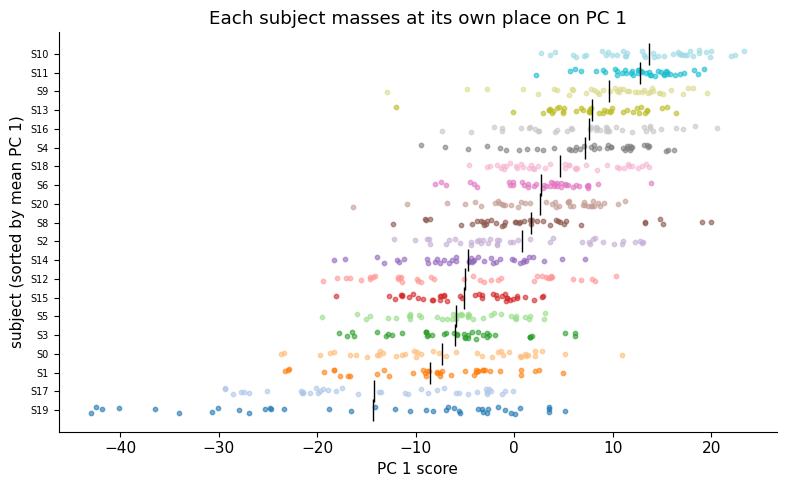

PC 1 variance that is between-SUBJECT:   57%
PC 1 variance that is between-CONDITION: 1.2%
PC 1 is essentially a subject-ID axis: it encodes WHO the person is, not what they were doing.


In [28]:
# TODO 8.1, your code here
subs  = np.unique(subject)                                              # TO BE REMOVED
order = np.argsort([Z[subject == s, 0].mean() for s in subs])          # sort subjects by mean PC1  # TO BE REMOVED
rng8  = np.random.default_rng(0)                                        # TO BE REMOVED
palette = plt.get_cmap('tab20')(np.linspace(0, 1, len(subs)))          # 19 distinct colours  # TO BE REMOVED
fig, ax = plt.subplots(figsize=(8, 5))                                  # TO BE REMOVED
for row, s in enumerate(subs[order]):                                   # TO BE REMOVED
    x = Z[subject == s, 0]                                              # TO BE REMOVED
    ax.scatter(x, row + rng8.uniform(-0.18, 0.18, x.size), s=10, alpha=0.6, color=palette[row])  # jittered epochs  # TO BE REMOVED
    ax.plot(x.mean(), row, '|', ms=16, color='black')                 # subject mean  # TO BE REMOVED
ax.set_yticks(range(len(subs))); ax.set_yticklabels([f'S{s}' for s in subs[order]], fontsize=7)  # TO BE REMOVED
ax.set_xlabel('PC 1 score'); ax.set_ylabel('subject (sorted by mean PC 1)')  # TO BE REMOVED
ax.set_title('Each subject masses at its own place on PC 1')           # TO BE REMOVED
plt.tight_layout(); plt.show()                                          # TO BE REMOVED

def eta2(score, groups):   # fraction of a PC's variance that lies BETWEEN groups  # TO BE REMOVED
    grp = np.unique(groups); mu = score.mean()                         # TO BE REMOVED
    ssb = sum((groups == k).sum() * (score[groups == k].mean() - mu) ** 2 for k in grp)  # TO BE REMOVED
    return ssb / ((score - mu) ** 2).sum()                             # TO BE REMOVED
print(f'PC 1 variance that is between-SUBJECT:   {eta2(Z[:, 0], subject)*100:.0f}%')  # TO BE REMOVED
print(f'PC 1 variance that is between-CONDITION: {eta2(Z[:, 0], cond)*100:.1f}%')     # TO BE REMOVED
print('PC 1 is essentially a subject-ID axis: it encodes WHO the person is, not what they were doing.')  # TO BE REMOVED

<a id="section-9"></a>
## 9. Reading a principal component

A PC is just a direction in feature space, and it is easy to over-read. Before trusting one as a result we
read it **critically**, what a PC can and cannot mean, and only then put it back on the **scalp** as a
topomap to see where the effect sits.


### Interpretation traps: a PC is not a neuron, a cause, or a generator

PCA returns the directions of maximal *variance* in your feature matrix. These are statistical axes, not
physiological objects. Common traps:

- **Not generators.** A single PC usually *mixes* channels and rhythms. PC 1 below spreads its weight across
  many electrodes and a band of frequencies, it is a broad *statistical* pattern, not "a generator" (and
  here PC 1 is a between-subject nuisance axis, not alpha at all).
- **Sign & rotation are arbitrary.** $\mathbf v$ and $-\mathbf v$ explain identical variance, so the sign of
  a score/loading is meaningless on its own.
- **Not causes.** A high loading ≠ causal importance. PCA is unsupervised and knows nothing about the
  eyes-open/closed labels.
- **Variance ≠ relevance.** The largest-variance direction can be an artefact (a blink, a noisy channel)
  rather than the effect of interest.

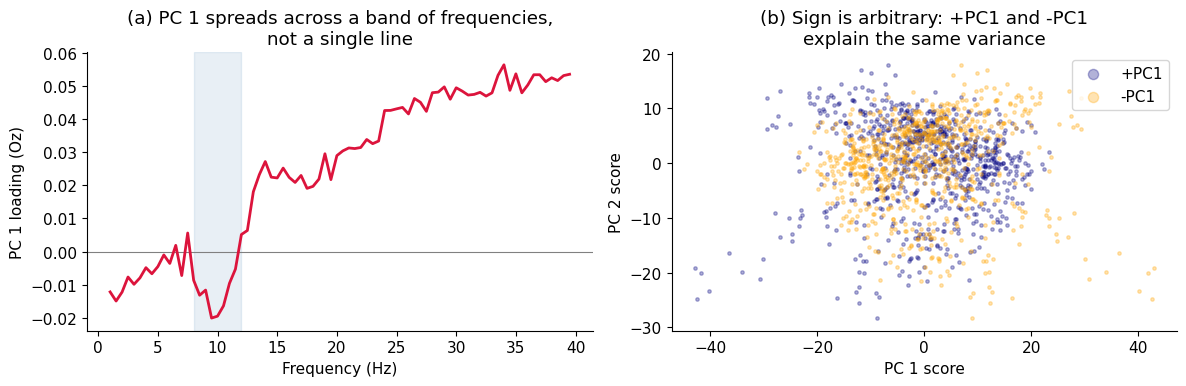

PC1 mixes many channels and a band of frequencies: a broad statistical axis, not one electrode,
not one rhythm, and (as Section 8 showed) not even the eyes-open/closed effect.


In [29]:
# --- A PC mixes channels/frequencies, and its sign is arbitrary (provided) ---
Zc = pca_alpha.transform(X_z)
_load_pc1 = pca_alpha.components_[0].reshape(n_ch, n_freq)[_oz]   # PC1 loading spectrum on Oz

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].plot(freq_axis, _load_pc1, color='crimson', lw=2)
axes[0].axvspan(ALPHA_LO, ALPHA_HI, color='steelblue', alpha=0.12)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('PC 1 loading (Oz)')
axes[0].set_title('(a) PC 1 spreads across a band of frequencies,\nnot a single line')
for sign, col, lbl in [(+1, 'navy', '+PC1'), (-1, 'orange', '-PC1')]:
    axes[1].scatter(sign*Zc[:, 0], Zc[:, 1], s=6, alpha=0.3, color=col, label=lbl)
axes[1].set_xlabel('PC 1 score'); axes[1].set_ylabel('PC 2 score')
axes[1].set_title('(b) Sign is arbitrary: +PC1 and -PC1\nexplain the same variance')
axes[1].legend(markerscale=3)
plt.tight_layout(); plt.show()
print('PC1 mixes many channels and a band of frequencies: a broad statistical axis, not one electrode,')
print('not one rhythm, and (as Section 8 showed) not even the eyes-open/closed effect.')

> **▶ Task 9.1: Read a component honestly. _(Medium)_**
>
> 1. Plot the PC 2 loading spectrum on Oz the same way as PC 1 above.
> 2. **Question (2–3 sentences):** a colleague says "PC 1 *is* the alpha rhythm, and its score measures how
>    active the alpha generator is." Give two reasons this is an over-statement, using what you see in the
>    loadings and the arbitrary sign.

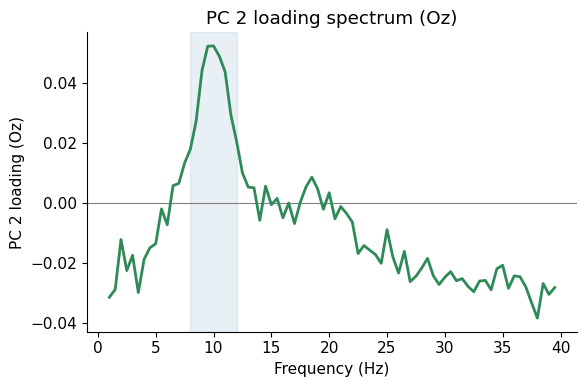

1) PC1 mixes a BAND of frequencies across MANY channels, a broad pattern, not one generator.
2) Its sign is arbitrary and PCA is unsupervised, so a high score marks position on a variance
   axis, not the physical "activity" of an alpha source.
3) PC1 does not even separate eyes-open/closed (Fisher ~ 0, Section 8); the effect is on PC2, not
   PC1. Calling PC1 "the alpha rhythm" is wrong on every count.


In [30]:
# TODO 9.1, your code here
_l2 = pca_alpha.components_[1].reshape(n_ch, n_freq)[_oz]                # TO BE REMOVED
fig, ax = plt.subplots(figsize=(6, 4))                                   # TO BE REMOVED
ax.axhline(0, color='gray', lw=0.8); ax.plot(freq_axis, _l2, color='seagreen', lw=2)  # TO BE REMOVED
ax.axvspan(ALPHA_LO, ALPHA_HI, color='steelblue', alpha=0.12)          # TO BE REMOVED
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PC 2 loading (Oz)')    # TO BE REMOVED
ax.set_title('PC 2 loading spectrum (Oz)'); plt.tight_layout(); plt.show()  # TO BE REMOVED
print('1) PC1 mixes a BAND of frequencies across MANY channels, a broad pattern, not one generator.')  # TO BE REMOVED
print('2) Its sign is arbitrary and PCA is unsupervised, so a high score marks position on a variance')  # TO BE REMOVED
print('   axis, not the physical "activity" of an alpha source.')                                       # TO BE REMOVED
print('3) PC1 does not even separate eyes-open/closed (Fisher ~ 0, Section 8); the effect is on PC2, not')  # TO BE REMOVED
print('   PC1. Calling PC1 "the alpha rhythm" is wrong on every count.')                  # TO BE REMOVED

### As a scalp map

Because every feature carries a **channel** label, we can put a principal component back on the head. For a
chosen PC, average its loadings over the **alpha band** (8-12 Hz) within each channel, giving one number
per electrode to draw as a **topomap**. We map PC 1 (the nuisance axis) and the condition PC identified in
Section 8, and ask where the eyes-open/closed effect actually sits on the scalp.


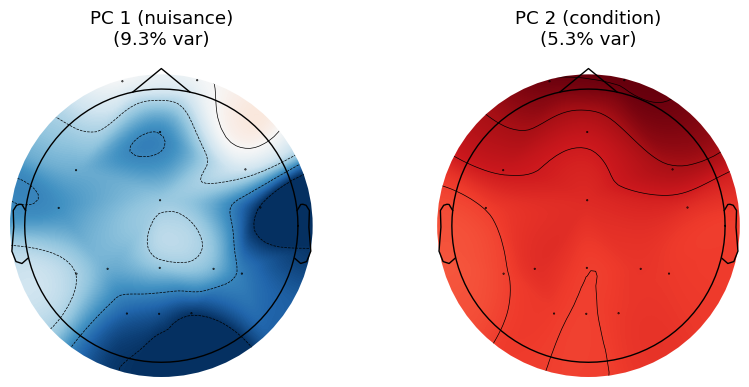

The condition axis (PC2) concentrates FRONTALLY (Fp1/Fp2/Fz), not occipitally.
The eyes-open/closed contrast PCA surfaces here is dominated by a frontal signal, largely ocular
(more blinks and eye-movement with the eyes open), foreshadowing the eye-blink component in Section 10.
The genuine occipital alpha increase is real (you saw it directly on Oz in Section 6) but it is a
smaller, subject-variable effect that does not dominate the variance.


In [31]:
# --- Scalp maps of the nuisance PC and the condition PC (provided) ---
# Build an MNE montage from the 10-20 channel names (match_case handles Fc5/FC5 etc.).
info = mne.create_info(ch_names, sfreq, ch_types='eeg')
info.set_montage('standard_1020', match_case=False, on_missing='ignore')

a_mask = (freq_axis >= ALPHA_LO) & (freq_axis < ALPHA_HI)
def pc_alpha_topo(pc):
    comp = pca_alpha.components_[pc].reshape(n_ch, n_freq)   # (channels, freqs)
    return comp[:, a_mask].mean(axis=1)                      # mean alpha-band loading per channel

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
mne.viz.plot_topomap(pc_alpha_topo(0), info, axes=axes[0], show=False, contours=4)
axes[0].set_title(f'PC 1 (nuisance)\n({ev[0]*100:.1f}% var)')
mne.viz.plot_topomap(pc_alpha_topo(cond_pc), info, axes=axes[1], show=False, contours=4)
axes[1].set_title(f'PC {cond_pc+1} (condition)\n({ev[cond_pc]*100:.1f}% var)')
plt.tight_layout(); plt.show()
print(f'The condition axis (PC{cond_pc+1}) concentrates FRONTALLY (Fp1/Fp2/Fz), not occipitally.')
print('The eyes-open/closed contrast PCA surfaces here is dominated by a frontal signal, largely ocular')
print('(more blinks and eye-movement with the eyes open), foreshadowing the eye-blink component in Section 10.')
print('The genuine occipital alpha increase is real (you saw it directly on Oz in Section 6) but it is a')
print('smaller, subject-variable effect that does not dominate the variance.')


> **▶ Task 9.2: Supervised vs unsupervised, do they agree? _(Hard, optional)_**
>
> PCA found the condition axis *unsupervised*. Compute the same contrast the *supervised* way and compare.
> 1. For each channel, take its mean alpha-band power (`X_psd`, 8-12 Hz columns) and compute
>    **eyes-closed - eyes-open**: a 16-value difference map.
> 2. Plot it as a topomap next to the **condition PC** map (`pc_alpha_topo(cond_pc)`). Do they highlight the
>    same electrodes? Is the biggest eyes-open/closed difference at the front or the back of the head?

<details>
<summary>💡 Hint (click to show)</summary>

- The alpha value per channel for a set of epochs: average `X_psd` over those rows, reshape to
  `(n_ch, n_freq)`, then average the `a_mask` (8-12 Hz) columns, exactly as `pc_alpha_topo` does for a
  component. Do it for the eyes-closed rows and the eyes-open rows, then subtract.
- Plot both maps with `mne.viz.plot_topomap(values, info, axes=..., show=False)` (reuse `info` from above).

</details>


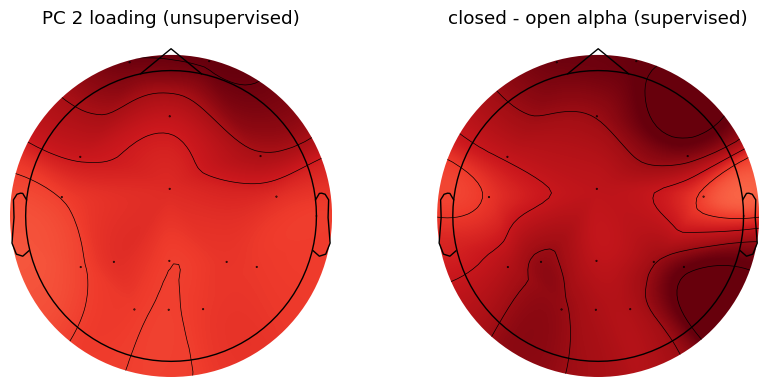

Both maps are frontally dominant (Fp1/Fp2/Fz, with some parietal) and agree: the largest
eyes-open/closed difference in these relative-power features is frontal, largely ocular, not the
textbook occipital alpha. Occipital sites do show the expected closed>open alpha (Section 6),
but it is not the dominant axis of variance here.


In [32]:
# TODO 9.2, eyes-closed minus eyes-open alpha topography
diff = np.zeros(n_ch)                                                    # TO BE REMOVED
for ch in range(n_ch):                                                  # TO BE REMOVED
    cols = np.where(a_mask)[0] + ch * n_freq                            # TO BE REMOVED
    diff[ch] = X_psd[cond==1][:, cols].mean() - X_psd[cond==0][:, cols].mean()  # TO BE REMOVED
fig, axes = plt.subplots(1, 2, figsize=(9, 4))                          # TO BE REMOVED
mne.viz.plot_topomap(pc_alpha_topo(cond_pc), info, axes=axes[0], show=False, contours=4)  # TO BE REMOVED
axes[0].set_title(f'PC {cond_pc+1} loading (unsupervised)')             # TO BE REMOVED
mne.viz.plot_topomap(diff, info, axes=axes[1], show=False, contours=4)  # TO BE REMOVED
axes[1].set_title('closed - open alpha (supervised)')                   # TO BE REMOVED
plt.tight_layout(); plt.show()                                          # TO BE REMOVED
print('Both maps are frontally dominant (Fp1/Fp2/Fz, with some parietal) and agree: the largest')  # TO BE REMOVED
print('eyes-open/closed difference in these relative-power features is frontal, largely ocular, not the')  # TO BE REMOVED
print('textbook occipital alpha. Occipital sites do show the expected closed>open alpha (Section 6),')  # TO BE REMOVED
print('but it is not the dominant axis of variance here.')             # TO BE REMOVED

<a id="section-10"></a>
## 10. Eye-blinks: PCA also surfaces the ocular artefact  *(optional, for your interest)*

In Section 9 the eyes-open/closed axis turned out to be **frontal**, and we called it *largely ocular*.
This section makes that concrete: that frontal signal is the **eye blink**. PCA is blind to what a
component *means*, it simply chases variance, and on raw EEG the single largest source of variance is
usually **not** the brain at all: it is the blink. Each blink drives a large, slow deflection that is
strongest over the **frontal** electrodes (Fp1, Fp2) and fades toward the back of the head.

We can see this directly. Instead of running PCA on spectral features, run it **spatially**, across the
16 channels, treating every time sample as an observation of a 16-dimensional vector. One spatial
component will concentrate on the **frontal** electrodes (the blink); another will concentrate
**occipitally** (the alpha rhythm from Part II). Because each channel has a scalp position, we can plot
every spatial component as a topomap and read off which is which.


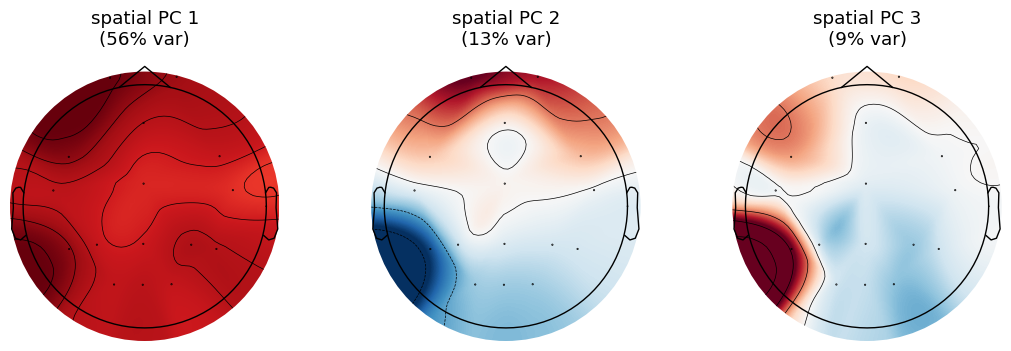

Most FRONTAL spatial component: PC 2 (13% of variance) -> the eye-blink pattern.
A separate occipital component (weighted on O1/Oz/O2) carries the alpha rhythm instead.


In [33]:
# --- Spatial PCA across the 16 channels: PCA surfaces the blink topography (provided) ---
# Reshape every epoch to (time sample, channel) and run PCA over the channels.
M = X_raw.transpose(0, 2, 1).reshape(-1, n_ch)      # (n_epochs*n_samples, 16)
M = M - M.mean(0)                                    # centre each channel
pca_spatial = PCA(n_components=6).fit(M)

# Scalp montage (same idea as §9).
info_sp = mne.create_info(ch_names, sfreq, ch_types='eeg')
info_sp.set_montage('standard_1020', match_case=False, on_missing='ignore')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, pc in zip(axes, range(3)):
    mne.viz.plot_topomap(pca_spatial.components_[pc], info_sp, axes=ax, show=False, contours=4)
    ax.set_title(f'spatial PC {pc+1}\n({pca_spatial.explained_variance_ratio_[pc]*100:.0f}% var)')
plt.tight_layout(); plt.show()

# Which component is the blink? The one weighted on the FRONTAL pair (Fp1/Fp2), not the occiput.
front = [ch_names.index(c) for c in ('Fp1', 'Fp2')]
occ   = [ch_names.index(c) for c in ('O1', 'Oz', 'O2')]
frontality = [np.abs(pca_spatial.components_[p])[front].mean()
              - np.abs(pca_spatial.components_[p])[occ].mean() for p in range(6)]
blink_pc = int(np.argmax(frontality))
print(f'Most FRONTAL spatial component: PC {blink_pc+1} '
      f'({pca_spatial.explained_variance_ratio_[blink_pc]*100:.0f}% of variance) -> the eye-blink pattern.')
print('A separate occipital component (weighted on O1/Oz/O2) carries the alpha rhythm instead.')


In [34]:
# --- Use the frontal component to detect blinks, per condition (provided) ---
# The blink component's score over time spikes at each blink. Flag the largest deflections.
tc      = pca_spatial.transform(M)[:, blink_pc].reshape(n_epochs, n_samples_epoch)
peak    = np.abs(tc).max(axis=1)                     # biggest frontal deflection in each epoch
thr     = np.percentile(peak, 60)                    # call the top deflections "a blink"
flagged = peak > thr

for c in (0, 1):
    pct = flagged[cond == c].mean() * 100
    print(f'{COND_NAMES[c]:12s}: {pct:4.0f}% of epochs contain a blink-sized frontal deflection')
print('We expect more blinks with the eyes OPEN (they are shut the rest of the time), check above.')


eyes open   :   48% of epochs contain a blink-sized frontal deflection
eyes closed :   32% of epochs contain a blink-sized frontal deflection
We expect more blinks with the eyes OPEN (they are shut the rest of the time), check above.


> **▶ Task 10.1: See the blinks in the frontal component. _(Medium, optional)_**
>
> Plot the blink component's time course (`tc`) for **one eyes-open epoch** and **one eyes-closed epoch**
> on the same axes, and draw the detection threshold (`±thr`). The eyes-open trace should show one or more
> sharp spikes (blinks) crossing the threshold; the eyes-closed trace should stay flatter. Use the
> condition colours in `COND_COLORS`.

<details>
<summary>💡 Hint (click to show)</summary>

- Pick an eyes-open epoch that actually contains a blink:
  `np.where(cond==0)[0][flagged[cond==0]][0]` (fall back to any open epoch if none were flagged).
- `tc[i]` is that epoch's blink-component time course; the time axis is `np.arange(n_samples_epoch)/sfreq`.

</details>


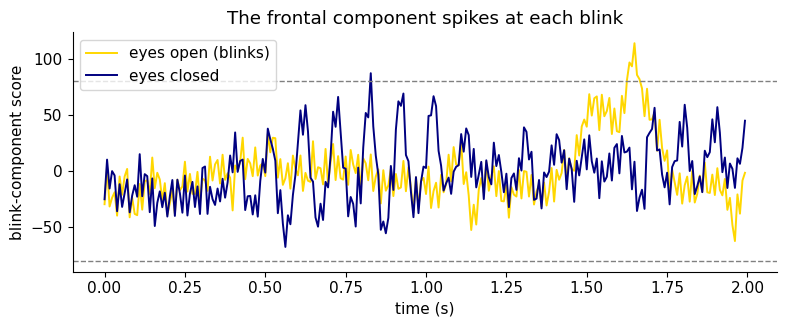

In [35]:
# TODO 10.1, blink component: eyes open vs eyes closed
t_ax    = np.arange(n_samples_epoch) / sfreq                                       # TO BE REMOVED
open_bl = np.where(cond == 0)[0][flagged[cond == 0]]                               # TO BE REMOVED
i_open  = int(open_bl[0]) if len(open_bl) else int(np.where(cond == 0)[0][0])      # TO BE REMOVED
i_close = int(np.where(cond == 1)[0][0])                                           # TO BE REMOVED
fig, ax = plt.subplots(figsize=(8, 3.4))                                           # TO BE REMOVED
ax.plot(t_ax, tc[i_open],  color=COND_COLORS[0], lw=1.4, label='eyes open (blinks)')   # TO BE REMOVED
ax.plot(t_ax, tc[i_close], color=COND_COLORS[1], lw=1.4, label='eyes closed')          # TO BE REMOVED
ax.axhline( thr, ls='--', color='gray', lw=1); ax.axhline(-thr, ls='--', color='gray', lw=1)  # TO BE REMOVED
ax.set_xlabel('time (s)'); ax.set_ylabel('blink-component score')                  # TO BE REMOVED
ax.set_title('The frontal component spikes at each blink'); ax.legend()            # TO BE REMOVED
plt.tight_layout(); plt.show()                                                     # TO BE REMOVED


> **Advanced: PCA _flags_ the blink, but ICA _removes_ it.**
> PCA surfaces the blink because it is high-variance, but it forces every component to be **orthogonal**
> to the others. Real brain activity is not orthogonal to the blink in sensor space, so brain signal leaks
> into the blink component (and vice versa): simply subtracting that component would also delete real
> signal. The standard tool for artefact **removal** is **ICA** (`mne.preprocessing.ICA` with
> `find_bads_eog`), which seeks statistically independent, non-Gaussian sources and isolates the blink
> cleanly. Below we run both on the same data and compare the blink component directly.


### Does ICA isolate the blink better than PCA?

PCA and ICA both return a set of spatial components, but they optimise different things. PCA maximises
**variance** and forces its components to be **orthogonal**. ICA maximises **statistical independence**
(equivalently, non-Gaussianity), with no orthogonality constraint. A blink is a sparse, spiky, highly
non-Gaussian event, so ICA can carve it into a single component; PCA cannot, because forcing
orthogonality smears the blink across several axes and lets brain signal leak in. Let us run both on
the same data and look at the first few components side by side.

New to these tools? See [independent component analysis](https://en.wikipedia.org/wiki/Independent_component_analysis);
the *non-Gaussianity* ICA maximises is quantified below with [kurtosis](https://en.wikipedia.org/wiki/Kurtosis)
(how "spiky" a distribution is).


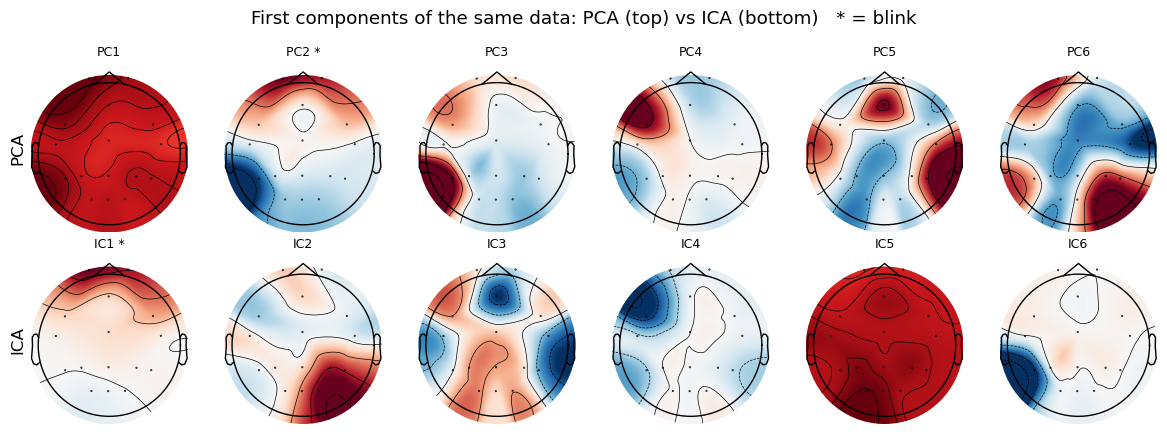

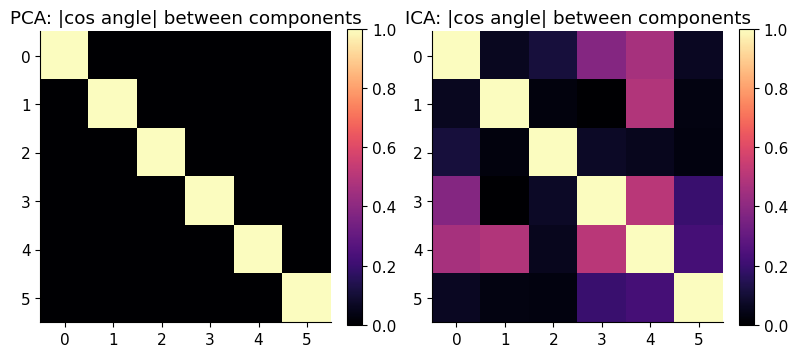

Largest |cos angle| between two DIFFERENT components:  PCA 0.00   ICA 0.51
PCA components are mutually ORTHOGONAL (off-diagonal ~ 0): a rigid, variance-ordered basis.
ICA components are NOT orthogonal (off-diagonal well above 0): independence is not orthogonality.


In [36]:
# --- The first few PCA vs ICA components, and their orthogonality (provided) ---
from sklearn.decomposition import FastICA

n_show = 6
# ICA on the same centred matrix M (pca_spatial was already fitted above).
ica      = FastICA(n_components=n_show, whiten='unit-variance', random_state=0, max_iter=1000)
S_ica    = ica.fit_transform(M)          # independent sources over time  (n_samples, n_show)
ica_topo = ica.mixing_.T                 # each row = one IC's scalp pattern  (n_show, n_ch)

# The blink component in each method = the most frontal spatial pattern (NOT a fixed index).
def _frontality(topos):
    return [np.abs(t)[front].mean() - np.abs(t)[occ].mean() for t in topos]
ic_blink = int(np.argmax(_frontality(ica_topo)))     # blink_pc (PCA) was found above

# (1) Same data, two decompositions -- are the components the same? Blink marked with *.
fig, axes = plt.subplots(2, n_show, figsize=(2.0 * n_show, 4.4))
for j in range(n_show):
    mne.viz.plot_topomap(pca_spatial.components_[j], info_sp, axes=axes[0, j], show=False, contours=4)
    axes[0, j].set_title(f'PC{j+1}' + (' *' if j == blink_pc else ''), fontsize=9)
    mne.viz.plot_topomap(ica_topo[j], info_sp, axes=axes[1, j], show=False, contours=4)
    axes[1, j].set_title(f'IC{j+1}' + (' *' if j == ic_blink else ''), fontsize=9)
axes[0, 0].set_ylabel('PCA', fontsize=12); axes[1, 0].set_ylabel('ICA', fontsize=12)
fig.suptitle('First components of the same data: PCA (top) vs ICA (bottom)   * = blink')
plt.tight_layout(); plt.show()

# (2) Orthogonality: |cos angle| between every pair of unit-normalised spatial patterns.
P  = pca_spatial.components_[:n_show]
A  = ica_topo[:n_show]
Pn = P / np.linalg.norm(P, axis=1, keepdims=True)
An = A / np.linalg.norm(A, axis=1, keepdims=True)
Gp, Ga = np.abs(Pn @ Pn.T), np.abs(An @ An.T)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
for a, G, name in zip(ax, (Gp, Ga), ('PCA', 'ICA')):
    im = a.imshow(G, vmin=0, vmax=1, cmap='magma')
    a.set_title(f'{name}: |cos angle| between components')
    a.set_xticks(range(n_show)); a.set_yticks(range(n_show))
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

off = lambda G: G[~np.eye(n_show, dtype=bool)].max()
print(f'Largest |cos angle| between two DIFFERENT components:  PCA {off(Gp):.2f}   ICA {off(Ga):.2f}')
print('PCA components are mutually ORTHOGONAL (off-diagonal ~ 0): a rigid, variance-ordered basis.')
print('ICA components are NOT orthogonal (off-diagonal well above 0): independence is not orthogonality.')


**What to notice.** Both panels describe the *same* data, yet the two component sets are different.
The PCA maps are **mutually orthogonal** (right figure: off-diagonal near 0), because PCA builds a rigid
orthonormal basis ordered by variance. The ICA maps are **not orthogonal** (off-diagonals well above 0):
ICA only requires the *sources* to be statistically independent, and independent generators (a blink, an
occipital rhythm, an electrode pop) need not sit at right angles on the scalp. That extra freedom is why
ICA can pack the whole blink into one focal frontal component (marked *), whereas PCA must split and mix
it across axes to stay orthogonal.


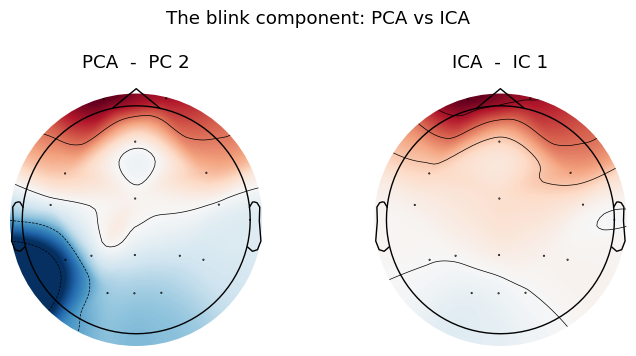

              frontal-focality   occipital-leak   |kurtosis|
  PCA blink        0.54            0.119         31.9
  ICA blink        0.86            0.004         50.1

ICA gives the blink a spikier (more non-Gaussian) source and a more focal frontal map with less
occipital leak; PCA, forced to stay orthogonal, smears the blink axis into other channels.
Note: the blink is chosen by its FRONTAL TOPOGRAPHY, not by kurtosis rank -- other ICs (e.g.
single-channel electrode pops) can be even more non-Gaussian but are not frontal.


In [37]:
# --- Zoom in on the blink component: PCA vs ICA (provided) ---
from scipy.stats import kurtosis

# Side-by-side topomaps of the blink component picked above (blink_pc for PCA, ic_blink for ICA).
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
mne.viz.plot_topomap(pca_spatial.components_[blink_pc], info_sp, axes=axes[0], show=False, contours=4)
axes[0].set_title(f'PCA  -  PC {blink_pc+1}')
mne.viz.plot_topomap(ica_topo[ic_blink], info_sp, axes=axes[1], show=False, contours=4)
axes[1].set_title(f'ICA  -  IC {ic_blink+1}')
fig.suptitle('The blink component: PCA vs ICA'); plt.tight_layout(); plt.show()

# Quantify: frontal focality, occipital leak, and non-Gaussianity (kurtosis) of the source.
focality = lambda t: (t**2)[front].sum() / (t**2).sum()
occ_leak = lambda t: (t**2)[occ].sum()   / (t**2).sum()
pc_src   = pca_spatial.transform(M)[:, blink_pc]
ic_src   = S_ica[:, ic_blink]
print('              frontal-focality   occipital-leak   |kurtosis|')
print(f'  PCA blink        {focality(pca_spatial.components_[blink_pc]):.2f}            '
      f'{occ_leak(pca_spatial.components_[blink_pc]):.3f}         {abs(kurtosis(pc_src)):.1f}')
print(f'  ICA blink        {focality(ica_topo[ic_blink]):.2f}            '
      f'{occ_leak(ica_topo[ic_blink]):.3f}         {abs(kurtosis(ic_src)):.1f}')
print()
print('ICA gives the blink a spikier (more non-Gaussian) source and a more focal frontal map with less')
print('occipital leak; PCA, forced to stay orthogonal, smears the blink axis into other channels.')
print('Note: the blink is chosen by its FRONTAL TOPOGRAPHY, not by kurtosis rank -- other ICs (e.g.')
print('single-channel electrode pops) can be even more non-Gaussian but are not frontal.')


> **Why are the two maps reversed in colour?** The PCA map may come out red at the front while the ICA
> map is blue there (or vice versa). That is not a disagreement: **the sign of a component is arbitrary in
> both methods.** A PCA loading vector $v$ and its negative $-v$ span the same axis and explain identical
> variance; an ICA source $s$ is equally valid as $-s$ once you also flip the sign of its mixing column, so
> the source stays just as independent. Each algorithm fixes the sign by an internal numerical convention,
> not by any physical rule, so the two can land on opposite polarities. Only the **spatial pattern**
> (frontal vs occipital) and the **magnitude** of the weights are meaningful here; the red/blue polarity is
> not. If you want them to match visually, multiply one component by $-1$. This is the same
> sign-arbitrariness you met when reading a component honestly in Section 9.


**Takeaway.** ICA gives a cleaner blink: a spikier (more non-Gaussian) source and a more focal frontal
map. That is exactly why artefact **removal** pipelines use ICA, not PCA: you can delete the single
blink IC and reconstruct the data with the brain signal essentially intact. With PCA, the blink
direction is entangled with real activity, so subtracting it also removes brain signal. PCA is still
useful to *detect* and *flag* the artefact (as above), but ICA is the tool that *removes* it.

> **Try at home _(Hard)_:** remove the blink component with each method (zero it out, then reconstruct
> with `inverse_transform`) and compare how much occipital alpha power survives. ICA should preserve more.


<a id="section-11"></a>
## 11. End-of-session exercises  *(at home)*

Combine the building blocks. You may freely copy and adapt earlier cells.

> **▶ Task 11.1: Reconstruct an epoch from k PCs. _(Medium, at home)_**
>
> Pick one eyes-closed epoch and reconstruct its feature vector from `k = 1, 2, 5, 20` PCs
> (`pca_alpha.inverse_transform`), reverse the z-scoring (`scaler.inverse_transform`), and plot the
> reconstructed **Oz** spectrum against the original. How many PCs before the alpha peak is captured?

<details>
<summary>💡 Hint (click to show)</summary>

- Keep the epoch 2-D: `x = X_z[[idx]]`. For each `k`, fit `pk = PCA(n_components=k).fit(X_z)`, then
  `scaler.inverse_transform(pk.inverse_transform(pk.transform(x)))` undoes the PCA *and* the z-scoring.
- The Oz columns of a feature row are `[_oz*n_freq:(_oz+1)*n_freq]`; plot them against `freq_axis`.

</details>


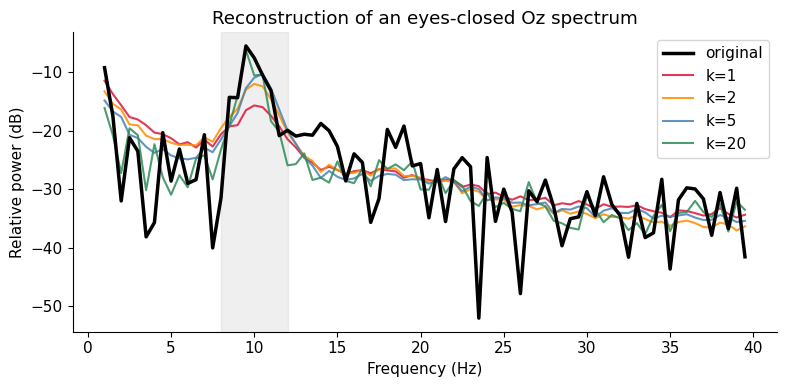

In [38]:
# TODO 11.1, epoch reconstruction from k PCs
_pool = np.where(cond == 1)[0]; idx = _pool[min(5, len(_pool)-1)]        # TO BE REMOVED
x_z   = X_z[[idx]]                                                       # TO BE REMOVED
orig  = X_psd[idx, _oz*n_freq:(_oz+1)*n_freq]                            # TO BE REMOVED
fig, ax = plt.subplots(figsize=(8, 4))                                   # TO BE REMOVED
ax.plot(freq_axis, orig, lw=2.5, color='black', label='original', zorder=5)  # TO BE REMOVED
for k, col in zip([1, 2, 5, 20], ['crimson','darkorange','steelblue','seagreen']):  # TO BE REMOVED
    pk = PCA(n_components=k).fit(X_z)                                    # TO BE REMOVED
    rec = scaler.inverse_transform(pk.inverse_transform(pk.transform(x_z)))[0, _oz*n_freq:(_oz+1)*n_freq]  # TO BE REMOVED
    ax.plot(freq_axis, rec, lw=1.5, alpha=0.85, color=col, label=f'k={k}')  # TO BE REMOVED
ax.axvspan(ALPHA_LO, ALPHA_HI, color='gray', alpha=0.12)                # TO BE REMOVED
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel(FEATURE_LABEL)          # TO BE REMOVED
ax.set_title('Reconstruction of an eyes-closed Oz spectrum'); ax.legend()  # TO BE REMOVED
plt.tight_layout(); plt.show()                                          # TO BE REMOVED

> **▶ Task 11.2: Alpha band power vs the full spectrum. _(Hard, at home)_**
>
> Build a compact feature matrix of **5 band powers per channel** (delta 1-4, theta 4-8, alpha 8-12,
> sigma 12-16, beta 16-30 Hz) by averaging `X_psd` within each band, and run PCA on it. Then compare its
> eyes-open/closed separation with the full-spectrum PCA. As in Section 8, **do not assume the effect is on
> PC 1**: for each feature set, scan the first few PCs with `fisher_ratio` and report the **best-separating
> PC**. Does the compact 80-feature version keep the effect, and on which PC does it land?


In [39]:
# TODO 11.2, band-power PCA vs full-spectrum PCA
BANDS = {'delta':(1,4), 'theta':(4,8), 'alpha':(8,12), 'sigma':(12,16), 'beta':(16,30)}   # TO BE REMOVED
Xb = np.zeros((n_epochs, n_ch*len(BANDS)))                              # TO BE REMOVED
for ei in range(n_epochs):                                             # TO BE REMOVED
    row = []                                                           # TO BE REMOVED
    for ch in range(n_ch):                                            # TO BE REMOVED
        seg = X_psd[ei, ch*n_freq:(ch+1)*n_freq]                       # TO BE REMOVED
        row += [seg[(freq_axis>=lo)&(freq_axis<hi)].mean() for lo,hi in BANDS.values()]  # TO BE REMOVED
    Xb[ei] = row                                                       # TO BE REMOVED
Zb = PCA().fit_transform(StandardScaler().fit_transform(Xb))          # TO BE REMOVED

# Select the best-separating PC in each space (do NOT assume PC 1), as in Section 8.  # TO BE REMOVED
def best_pc(scores):                                                   # TO BE REMOVED
    f = [fisher_ratio(scores[:, k], cond) for k in range(min(5, scores.shape[1]))]  # TO BE REMOVED
    k = int(np.argmax(f)); return k, f[k]                              # TO BE REMOVED
kb, fb = best_pc(Zb)                                                    # TO BE REMOVED
kf, ff = best_pc(Z)                                                    # TO BE REMOVED
print(f'band power ({Xb.shape[1]:4d} features): best PC{kb+1}, Fisher {fb:.2f}')  # TO BE REMOVED
print(f'full PSD   ({X_psd.shape[1]:4d} features): best PC{kf+1}, Fisher {ff:.2f}')  # TO BE REMOVED
print('The 80-feature band-power version keeps essentially all the separation, and the effect rises to')  # TO BE REMOVED
print('PC 1 (vs PC 2 for the full spectrum): fewer, cleaner features let the condition dominate the')  # TO BE REMOVED
print('leading axis instead of being buried under between-subject nuisance.')  # TO BE REMOVED

band power (  80 features): best PC1, Fisher 0.16
full PSD   (1248 features): best PC2, Fisher 0.16
The 80-feature band-power version keeps essentially all the separation, and the effect rises to
PC 1 (vs PC 2 for the full spectrum): fewer, cleaner features let the condition dominate the
leading axis instead of being buried under between-subject nuisance.


<a id="section-12"></a>
## 12. Factor analysis and PLS

PCA is not the only game in town. Two close relatives answer questions PCA cannot: **factor analysis**
separates shared structure from per-feature noise, while **PLS** makes use of the labels PCA ignores.
Both are optional extensions to explore after the session.


### Factor analysis: shared variance vs maximal variance  *(optional extension)*

**PCA** finds orthogonal directions capturing the *total* variance, treating every
feature's variance (signal + noise) equally. **Factor analysis (FA)** instead models the
data as a few **shared latent factors** plus **per-feature unique noise**:

$$\mathbf x = \boldsymbol\Lambda \mathbf f + \boldsymbol\varepsilon,
\qquad \text{Cov}(\boldsymbol\varepsilon) = \boldsymbol\Psi\ \text{(diagonal)}$$

Because FA gives each feature its own noise variance $\Psi_{jj}$, it ignores variance
that is *not shared* across features. PCA cannot: a single noisy feature with large
variance hijacks PC 1. The demo shows exactly that.

(Background: [factor analysis](https://en.wikipedia.org/wiki/Factor_analysis).)


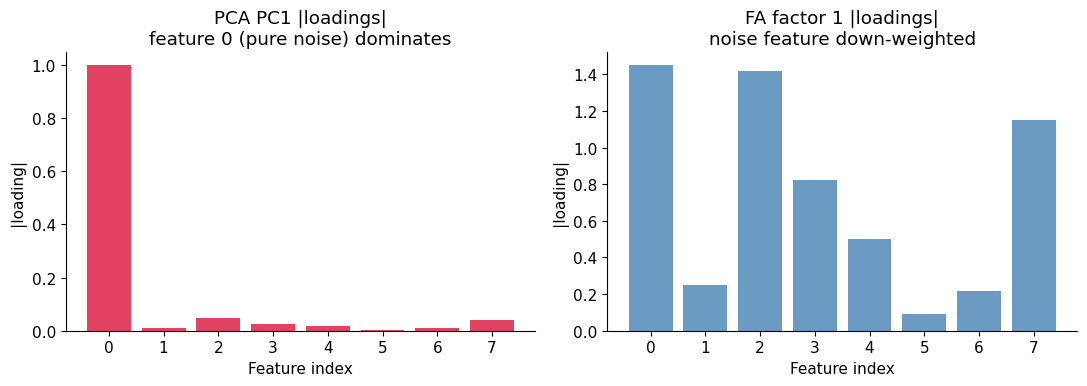

FA per-feature noise variance (uniqueness): [1.   0.12 0.01 0.3  0.12 0.09 0.47 0.23]
-> FA models feature 0 as mostly private noise; PCA lumps it into PC1.


In [40]:
# --- PCA is hijacked by one noisy feature; FA is not (provided)
from sklearn.decomposition import FactorAnalysis
rng_fa = np.random.default_rng(0)
F   = rng_fa.standard_normal((500, 2))           # 2 shared latent factors
L   = rng_fa.standard_normal((8, 2))             # loadings onto 8 features
Xfa = F @ L.T + 0.3 * rng_fa.standard_normal((500, 8))
Xfa[:, 0] += 6.0 * rng_fa.standard_normal(500)   # feature 0 = large PRIVATE noise

pca_fa = PCA(n_components=2).fit(Xfa)
fa     = FactorAnalysis(n_components=2, random_state=0).fit(Xfa)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(8), np.abs(pca_fa.components_[0]), color='crimson', alpha=0.8)
axes[0].set_title('PCA PC1 |loadings|\nfeature 0 (pure noise) dominates')
axes[1].bar(np.arange(8), np.abs(fa.components_[0]), color='steelblue', alpha=0.8)
axes[1].set_title('FA factor 1 |loadings|\nnoise feature down-weighted')
for ax in axes: ax.set_xlabel('Feature index'); ax.set_ylabel('|loading|')
plt.tight_layout(); plt.show()
print('FA per-feature noise variance (uniqueness):', fa.noise_variance_.round(2))
print('-> FA models feature 0 as mostly private noise; PCA lumps it into PC1.')

### Where PLS fits: the supervised cousin of PCA  *(optional extension)*

PCA is **unsupervised**: it finds large-variance directions in $X$ alone, ignoring any
outcome. **Partial Least Squares (PLS)** is **supervised**: it finds the directions in
$X$ that *covary most with a target* $Y$. When the variance you care about (the part
predictive of $Y$) is small next to nuisance variance, PCA's top component can miss it
while PLS locks on. (You will meet PLS again for regression with many collinear
predictors.)

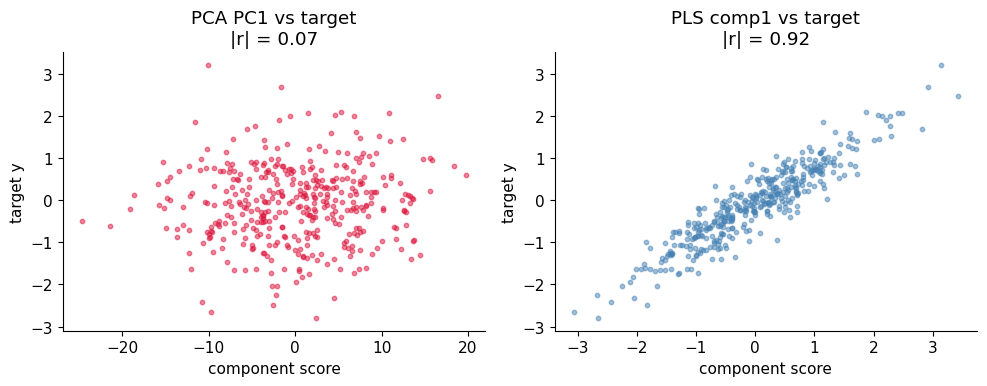

PCA PC1 follows the high-variance nuisance; PLS comp1 aligns with y.


In [41]:
# --- PCA chases variance; PLS chases the target (provided)
from sklearn.cross_decomposition import PLSRegression
rng_pls = np.random.default_rng(1)
n = 400
sig   = rng_pls.standard_normal(n)        # predictive latent (small amplitude)
noise = rng_pls.standard_normal(n)        # high-variance nuisance latent
Xp = (np.column_stack([5.0*noise + 0.2*sig, 5.0*noise - 0.2*sig, 0.3*sig])
      + 0.1*rng_pls.standard_normal((n, 3)))
y  = sig + 0.1*rng_pls.standard_normal(n)  # target depends only on `sig`

pc1  = PCA(n_components=1).fit(Xp).transform(Xp)[:, 0]
pls1 = PLSRegression(n_components=1).fit(Xp, y).transform(Xp)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pc1,  y, s=10, alpha=0.5, color='crimson')
axes[0].set_title(f'PCA PC1 vs target\n|r| = {abs(np.corrcoef(pc1, y)[0,1]):.2f}')
axes[1].scatter(pls1, y, s=10, alpha=0.5, color='steelblue')
axes[1].set_title(f'PLS comp1 vs target\n|r| = {abs(np.corrcoef(pls1, y)[0,1]):.2f}')
for ax in axes: ax.set_xlabel('component score'); ax.set_ylabel('target y')
plt.tight_layout(); plt.show()
print('PCA PC1 follows the high-variance nuisance; PLS comp1 aligns with y.')

<a id="about"></a>
## 13. About this notebook

**Dataset.** EEG **Alpha Waves** (Cattan, Rodrigues & Congedo, GIPSA-lab; Zenodo
`10.5281/zenodo.2348892`, CC-BY-4.0): 20 subjects, 16-channel 10-20 EEG at 512 Hz, resting state with
alternating **eyes-closed / eyes-open** blocks. Shipped with the repo as `data/alphawaves.npz`,
**repackaged** from the original Zenodo `.mat` files (raw 10-s blocks; see `data/eeg_datadictionary.md`),
and epoched in the notebook to 2-s epochs at 128 Hz. `data_prep/build_alpha_dataset.py` can rebuild it from Zenodo.

**Concepts → code map.**
- *Covariance & eigenvectors* → `np.cov`, `np.linalg.eigh`; PC arrows on the 2-D grades.
- *PCA / SVD* → `sklearn.decomposition.PCA`, `np.linalg.svd`; scores, loadings, `explained_variance_ratio_`.
- *How many PCs* → scree + cumulative variance; reconstruction; band-power vs full spectrum.
- *Preprocessing* → centering, scaling (`StandardScaler`), whitening (`whiten=True`).
- *Spectral features* → one FFT per epoch per channel (`np.fft.rfft`, `|FFT|²`), relative power in dB.
- *Reading a PC spatially* → reshape loadings to (channel, frequency); `mne.viz.plot_topomap` scalp maps.
- *Artefacts* → spatial PCA across channels surfaces the frontal eye-blink; PCA flags it, ICA removes it.
- *Limits & neighbours* → interpretation traps; factor analysis; PLS.

**Further reading.**
- Cattan et al. (2018) *EEG Alpha Waves dataset*, Zenodo 10.5281/zenodo.2348892.
- Pfurtscheller, Stancák & Neuper (1996) *Int J Psychophysiol* 24:39, alpha as cortical idling.
- Shlens (2014) *A Tutorial on Principal Component Analysis*, arXiv:1404.1100.
- Cunningham & Yu (2014) *Nature Neuroscience* 17:1500, dimensionality reduction for neural data.

**Credits.** Week 11, Responsible TA: Theo, contributing TAs: Nosrat & Riccardo. Quantitative Methods in Neuroscience,
University of Geneva (2026-27).